# Exploratory Data Analysis and Product Comparison for Beats by Dre:

### NOTE: ###
This is a copy of the original notebook that I worked on the original can be found on Google Colab right here: https://colab.research.google.com/drive/1TSaVx5vnQtEjOWuK7mcOADBBtNFkY9uE?usp=sharing

## Introduction and Project Outline:
This EDA will consist of a few different parts and will revolve around selecting a product that occupies a specific niche in the wireless speaker headphone space and the outline is as follows:
1) Isolating key products by adding the product name as an alternative to the Amazon ID, ensuring all products are a similar price range and segmenting products by keeping 1 Beats products and comparing to 4 competitor products.
2) Data inspection and preprocessing.
3) Conducting analysis on products and creating visuals to ensure data storytelling paints accurate pictures and delivers unique insights into product niche. **Note will be using pandas and numpy to perform analysis.**

## Data Inspection and Preprocessing:

In [1]:
#importing necessary libraries
import nltk
import os
import time
import google.genai as genai
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
from IPython.display import display, Markdown
from matplotlib import pyplot as plt
from nltk.tokenize import word_tokenize
from sqlalchemy import create_engine
from textblob import TextBlob
from wordcloud import WordCloud


In [2]:
url = "https://raw.githubusercontent.com/michaelms123/Amazon-Reviews-Project/main/new_reference_data_for_beats.csv"

In [3]:
#storing in products_df
products_df = pd.read_csv(url)

In [4]:
top_products = products_df['product_id'].value_counts().head(10)
top_products

,count
product_id,
B08X4YMTPM,125
B096SV8SJG,123
B09XXW54QG,115
B0CXL4FQBK,105
B08ZR5JB9G,102
B0B43Y8GHZ,102
B099TLMRB6,101
B09HN594TL,100
B0C2F5KD26,100


In [5]:
#overview of data
products_df.head()

,review_id,product_id,title,author,rating,content,timestamp,profile_id,is_verified,helpful_count,product_attributes
0,R1TIU27G892G8N,B09GJVTRNZ,5.0 out of 5 stars Best for modern music; fine...,Glut & Lack: troublemaking twins,5,Love this little speaker for the music I (and ...,"Reviewed in the United States January 14, 2025",AEMU5GYR7E7YH5B64AKBUNZ5Y4PA,1,19,"Color: Blue, Style: Flip 6"
1,R3UHPD69SUVF4D,B09GJVTRNZ,5.0 out of 5 stars Incredible Sound and Perfor...,Seva,5,I recently bought the JBL Flip 6 Portable Blue...,"Reviewed in the United States January 4, 2025",AF2OOF3FJWVX65HP72K6CVPMONRA,1,14,"Color: Teal, Style: Flip 6"
2,R8ZPP4M7T18BO,B09GJVTRNZ,5.0 out of 5 stars The Sound Is Great,Michelle,5,I'm so glad I bought this. I use it daily I ha...,"Reviewed in the United States April 16, 2025",AHHSFRGEAFWTV24U7MFCK7V54P7Q,1,1,"Color: Blue, Style: Flip 6"
3,R3T9HSXO492VDG,B09GJVTRNZ,5.0 out of 5 stars Incredible Sound and Durabi...,Paola J Franco,5,The sound quality is amazing for such a compac...,"Reviewed in the United States February 28, 2025",AGIUPLMVY4PLRDFR6DCBYAG53LWQ,1,6,"Color: White, Style: Flip 6"
4,RF4X9MUCFL4QZ,B09GJVTRNZ,5.0 out of 5 stars Not too small Not too big,Nikki Fox,5,"These are not huge, but great for my sports pl...","Reviewed in the United States April 17, 2025",AEP7HYGSBZ5Q2DII5UM2CWYXUQUA,1,1,"Color: Blue, Style: Flip 6"


In [6]:
products_df.tail()

,review_id,product_id,title,author,rating,content,timestamp,profile_id,is_verified,helpful_count,product_attributes
4985,R2YE8KKVZGETCW,B0CY6S748H,4.0 out of 5 stars Quality speaker,SC,4,OK I'll start with the elephant in the room......,"Reviewed in the United States June 12, 2024",AGSZPUV3HVYEEYXWLNDAMC4ODM5Q,0,0,Color: Black
4986,RERGCQ3PLJUTJ,B0CY6S748H,1.0 out of 5 stars Buyer beware WiFi connectio...,Road Runner,1,"I bought this speaker 6 months ago, barely use...","Reviewed in the United States June 2, 2024",AEGCJLZHMRVLF55FNZBSFVM2Y5PA,0,0,Color: White
4987,R25VEKRF5EV836,B0CY6S748H,1.0 out of 5 stars Horrible service,Linda T.,1,I could not link to other Sonos Roam speakers ...,"Reviewed in the United States May 24, 2024",AEECURQVZUBV4HKCK3M74UANCFKA,0,0,Color: Black
4988,R34PNR72XAULLC,B0CY6S748H,1.0 out of 5 stars Cannot pair two of these wi...,jdawz,1,"Amazing that they made an outdoor, portable wa...","Reviewed in the United States May 22, 2024",AFNED7OI2U3V2GPP6XHXMYQY5R6Q,0,0,Color: White
4989,R1GHYH6N4V9BRB,B0CY6S748H,1.0 out of 5 stars Spotty Qi charging and conn...,TheMeiers,1,Not consistent qi charging and bluetooth a pai...,"Reviewed in the United States May 24, 2024",AFW6USPKXJEMNISGCXPG2BFMALAQ,0,0,Color: Black


In [7]:
#renaming content column to make it more understandable
products_df.rename(columns={'content': 'review'}, inplace=True)

In [8]:
#all of these products are in the $120-250 range making them comparable in price
product_mapping = {
    'B08X4YMTPM': 'JBL Charge 5',
    'B09XXW54QG': 'Marshall Emberton II',
    'B0CXL4FQBK': 'Sony ULT Field 1',
    'B099TLMRB6': 'Bose Soundlink Flex',
    'B0D4STD5ZC': 'Beats Pill'
}
#creating product name column and dropping product id column
products_df = products_df[products_df['product_id'].isin(product_mapping.keys())]
products_df['product_name'] = products_df['product_id'].map(product_mapping)
products_df = products_df.drop('product_id', axis=1)

#calculating review lengths
products_df['review_lengths'] = np.array([len(review.split()) for review in products_df['review']])
products_df['review_lengths'].head()

,review_lengths
16,238
17,1239
18,99
19,61
20,28


In [9]:
#general info of data
products_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 501 entries, 16 to 4572
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   review_id           501 non-null    object
 1   title               501 non-null    object
 2   author              501 non-null    object
 3   rating              501 non-null    int64 
 4   review              501 non-null    object
 5   timestamp           501 non-null    object
 6   profile_id          501 non-null    object
 7   is_verified         501 non-null    int64 
 8   helpful_count       501 non-null    int64 
 9   product_attributes  501 non-null    object
 10  product_name        501 non-null    object
 11  review_lengths      501 non-null    int64 
dtypes: int64(4), object(8)
memory usage: 50.9+ KB


In [10]:
products_df['review_date_clean'] = pd.to_datetime(products_df['timestamp'].str.replace('Reviewed in the United States ', '', regex=False), format='%B %d, %Y')
products_df.head()

,review_id,title,author,rating,review,timestamp,profile_id,is_verified,helpful_count,product_attributes,product_name,review_lengths,review_date_clean
16,R1V1VE2DAH2VT4,5.0 out of 5 stars Great sound and perfect gift,Daniel,5,I bought the JBL Charge 5 as a Christmas gift ...,"Reviewed in the United States March 26, 2025",AE6J7WB6CFUL4TXIJRZUKPNYFPAA,1,6,Color: Black,JBL Charge 5,238,2025-03-26
17,R3AK5LLZ1VVTWJ,"5.0 out of 5 stars INSANE Speaker! Quality, vo...",Jeremy,5,The JBL Charge 5 is the BEST speaker I have ev...,"Reviewed in the United States April 5, 2024",AEDM32EKQE2HOHUCSXFF2Z27F7NQ,1,163,Color: Black,JBL Charge 5,1239,2024-04-05
18,R3RKDJFQLNMHYE,5.0 out of 5 stars Overall an excellent produc...,Elizabeth A. Krause,5,we love the speaker! It works so well outside ...,"Reviewed in the United States February 16, 2025",AHWTB6LQVFEKQJKIYCZLEFIL5J3A,1,2,Color: Black,JBL Charge 5,99,2025-02-16
19,R1JW17NN9PVA1W,5.0 out of 5 stars New favorite,Rachel,5,Amazing speaker. Sound quality is amazing. The...,"Reviewed in the United States March 23, 2025",AETLEBPDO6SRZXK7CJKH5KQ2ND2A,1,0,Color: Gray,JBL Charge 5,61,2025-03-23
20,R30K8G1EQTAYDC,5.0 out of 5 stars High quality product,Pinky,5,"Bigger than expected, sounds quality is perfec...","Reviewed in the United States April 17, 2025",AHSLXHRABQSSRSWWWPD2PQ56CLLA,1,0,Color: Camouflage,JBL Charge 5,28,2025-04-17


In [11]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 501 entries, 16 to 4572
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   review_id           501 non-null    object        
 1   title               501 non-null    object        
 2   author              501 non-null    object        
 3   rating              501 non-null    int64         
 4   review              501 non-null    object        
 5   timestamp           501 non-null    object        
 6   profile_id          501 non-null    object        
 7   is_verified         501 non-null    int64         
 8   helpful_count       501 non-null    int64         
 9   product_attributes  501 non-null    object        
 10  product_name        501 non-null    object        
 11  review_lengths      501 non-null    int64         
 12  review_date_clean   501 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(4), object(8)
memory usag

In [12]:
products_df.isna().sum()

,0
review_id,0
title,0
author,0
rating,0
review,0
timestamp,0
profile_id,0
is_verified,0
helpful_count,0
product_attributes,0


In [13]:
products_df.duplicated().sum()

np.int64(0)

## Review and Ratings Statistical Descriptions and Visualisations:

In [14]:
#statistical descriptions of rating and review length columns
print(f'General Description:\n{products_df[['rating', 'review_lengths']].describe()}')
print(f'\nMode\n{products_df[['rating', 'review_lengths']].mode()}')
print(f'\nMedian:\n{products_df[['rating', 'review_lengths']].median()}')
print(f'\nVariance:\n{products_df[['rating', 'review_lengths']].var()}')

General Description:
           rating  review_lengths
count  501.000000      501.000000
mean     4.756487       96.247505
std      0.636068      162.794848
min      1.000000        1.000000
25%      5.000000       18.000000
50%      5.000000       42.000000
75%      5.000000       99.000000
max      5.000000     1239.000000

Mode
   rating  review_lengths
0       5               7

Median:
rating             5.0
review_lengths    42.0
dtype: float64

Variance:
rating                0.404583
review_lengths    26502.162619
dtype: float64


/tmp/ipykernel_2706/1097725552.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='product_name', y='rating', data=avg_rating, palette='muted')


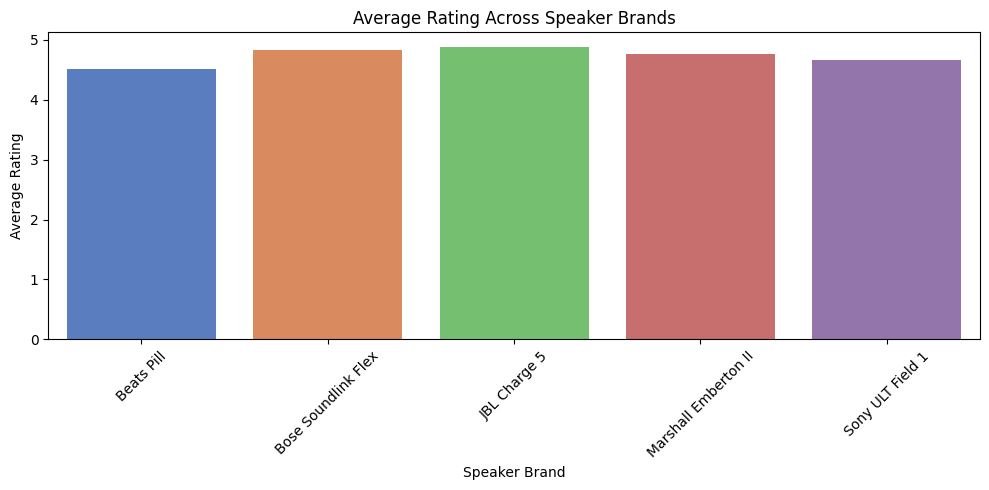

In [15]:
#comparing average rating across brands
avg_rating = products_df.groupby('product_name')['rating'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(x='product_name', y='rating', data=avg_rating, palette='muted')
plt.title('Average Rating Across Speaker Brands')
plt.xlabel('Speaker Brand')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.tight_layout()


### Conclusions/Insights Average Rating by Brand:
- Can see that the Beats Pill is the worst rated on average and the Bose JBL Charge 5 has the highest rating overall.
- However we do not know how many ratings there are for the Beats Pill in relation to the other brands (which are all around 100-120 ratings each) meaning further analysis is needed.

Text(0, 0.5, 'Frequency of Review of Specific Length')

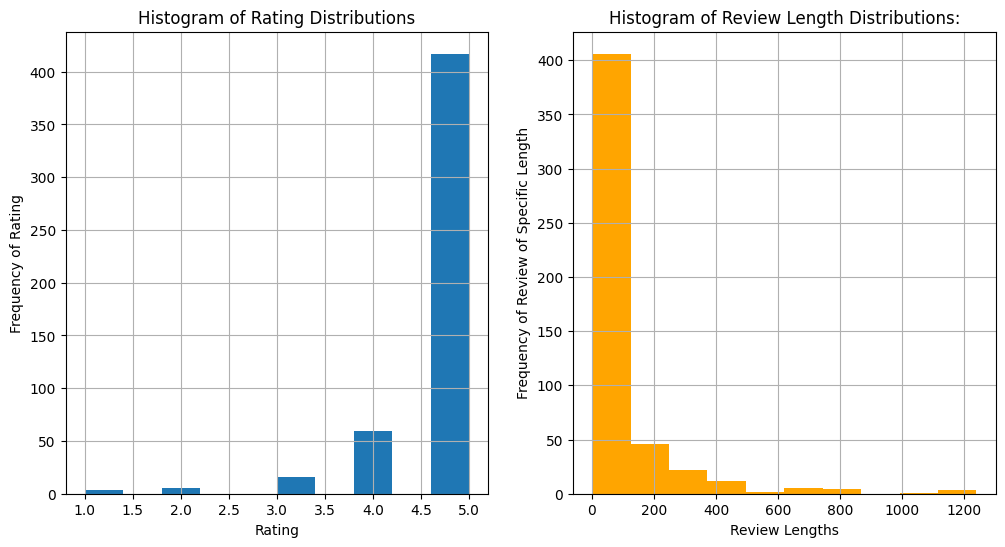

In [16]:
#general distributions of rating and review_lengths
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
products_df['rating'].hist(ax=axs[0])
axs[0].set_title('Histogram of Rating Distributions')
axs[0].set_xlabel('Rating')
axs[0].set_ylabel('Frequency of Rating')

products_df['review_lengths'].hist(ax=axs[1], color='orange')
axs[1].set_title('Histogram of Review Length Distributions:')
axs[1].set_xlabel('Review Lengths')
axs[1].set_ylabel('Frequency of Review of Specific Length')


### Conclusions/Insights on Rating and Review Length Distributions:
**Ratings:**

- Can see the most common rating is between 4.5-5.0 range (indicating general happiness with speakers)
- Can see that there is some assumed correlation with review lengths as the high rating counts are mirrored in the shorter review lengths.

**Review Lengths:**

- Can see that the most common word counts are between 0-100 words.
- Reviews with a word count over 300 are very uncommon and can most likely be considered outliers.
- Due to the positive nature of our reviews overall and how these distributions line up we can likely assume that positive reviews are shorter, while negative reviews tend to be longer.

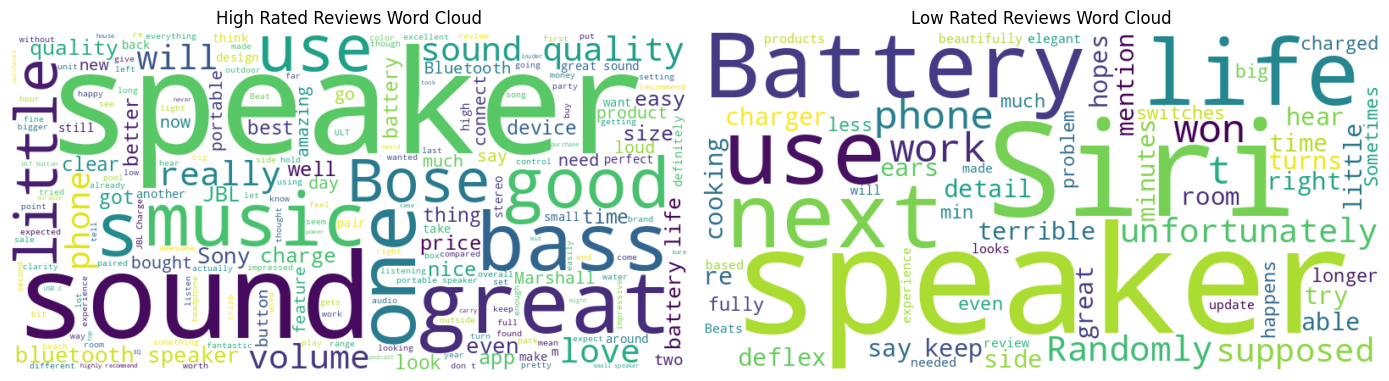

In [17]:
#word cloud for good and bad review descriptions
high_rated = " ".join(review for review in products_df[products_df['rating'] >= 4]['review'])
low_rated = " ".join(review for review in products_df[products_df['rating'] <= 1]['review'])

high_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(high_rated)
low_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(low_rated)

fig, axs = plt.subplots(1, 2, figsize=(14, 8))

axs[0].imshow(high_wordcloud, interpolation='bilinear')
axs[0].axis('off')
axs[0].set_title('High Rated Reviews Word Cloud', fontsize=12)

axs[1].imshow(low_wordcloud, interpolation='bilinear')
axs[1].axis('off')
axs[1].set_title('Low Rated Reviews Word Cloud', fontsize=12)

plt.tight_layout()

### Wordclouds for Positive and Negative Reviews:
- Speaker is prevalent in both (naturally) however words like great, love, highly recommend are present in positive wordcloud and not negative.
- Words like problem, old, dead and randomly are found in the negative word cloud.

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
/tmp/ipykernel_2706/1983354457.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='word', data=common_words, palette='viridis')


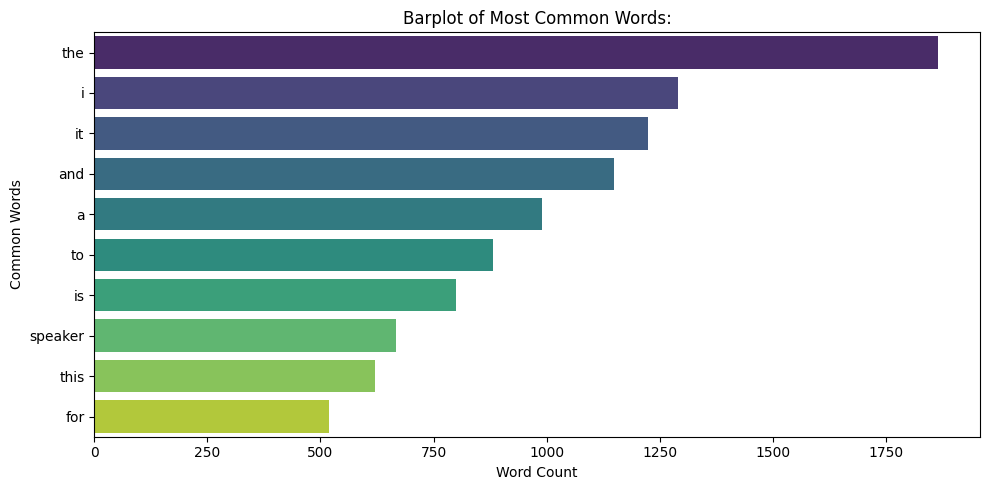

In [18]:
#creating a bar chart for top 10 most frequent words
nltk.download('punkt_tab')
five_star_rev = " ".join(review for review in products_df[products_df['rating'] == 5]['review'])
tokens = word_tokenize(five_star_rev.lower())
words_only = [word for word in tokens if word.isalnum()]

common_words = Counter(words_only).most_common(10)
common_words = pd.DataFrame(common_words, columns=['word', 'count'])

plt.figure(figsize=(10, 5))
sns.barplot(x='count', y='word', data=common_words, palette='viridis')
plt.title('Barplot of Most Common Words:')
plt.xlabel('Word Count')
plt.ylabel('Common Words')
plt.tight_layout()

### Conclusions/Insights for Ten Most Common Words:
- Most common words are filler words (and, the, it, i, etc.)
- The only adjective that appears is speaker and this does not offer much insight into review wording appearances just that people are reviewing speakers (which we know).

In [19]:
#IQR and outlier calculations
cols = ['rating', 'review_lengths']

for col in cols:
  q1 = products_df[col].quantile(0.25)
  q3 = products_df[col].quantile(0.75)
  iqr = q3 - q1

  lower_bound = (q1 - 1.5 * iqr)
  upper_bound = (q3 + 1.5 * iqr)
  mask = (products_df[col] < lower_bound) | (products_df[col] > upper_bound)
  outliers = products_df.loc[mask, ['rating', 'review_lengths']]

  print(f'{col}_q1: {q1}')
  print(f'{col}_q3: {q3}\n')
  print(f'{col}_outliers:\n{outliers}')

rating_q1: 5.0
rating_q3: 5.0

rating_outliers:
      rating  review_lengths
22         4              25
1048       4              43
1052       3             129
1081       4             101
1110       4             317
...      ...             ...
4351       4             270
4352       4             270
4457       4             101
4459       3             707
4565       4             317

[84 rows x 2 columns]
review_lengths_q1: 18.0
review_lengths_q3: 99.0

review_lengths_outliers:
      rating  review_lengths
16         5             238
17         5            1239
1045       5            1096
1047       5             639
1049       5             239
1051       5             279
1053       5             253
1054       5             459
1075       5            1239
1076       5             402
1083       5             240
1107       5             815
1110       4             317
1114       4             290
1230       5             416
1280       5             387
1405       5  

In [20]:
#normalising rating data for analysis potential model training
min = np.min(products_df['rating'])
max = np.max(products_df['rating'])

products_df['normalised_ratings'] = (products_df['rating'] - min) / (max - min)
products_df['normalised_ratings'].describe()

,normalised_ratings
count,501.000000
mean,0.939122
std,0.159017
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


In [21]:
products_df['year'] = products_df['review_date_clean'].dt.year
total_counts_rating = products_df.groupby(['product_name', 'year'])['rating'].agg(['mean', 'count'])
total_counts_rating

mean  count
product_name         year                 
Beats Pill           2024  4.509091     55
Bose Soundlink Flex  2024  4.831683    101
JBL Charge 5         2023  3.000000      2
                     2024  4.913793    116
                     2025  4.857143      7
Marshall Emberton II 2022  5.000000      3
                     2023  4.750000      8
                     2024  4.750000    104
Sony ULT Field 1     2024  4.666667    105

In [22]:
counts_per_rating = products_df.groupby(['product_name', 'rating']).size().unstack(fill_value=0)
counts_per_rating

rating,1,2,3,4,5
product_name,,,,,
Beats Pill,3,2,3,3,44
Bose Soundlink Flex,0,0,1,15,85
JBL Charge 5,0,0,3,9,113
Marshall Emberton II,0,0,4,20,91
Sony ULT Field 1,1,3,5,12,84


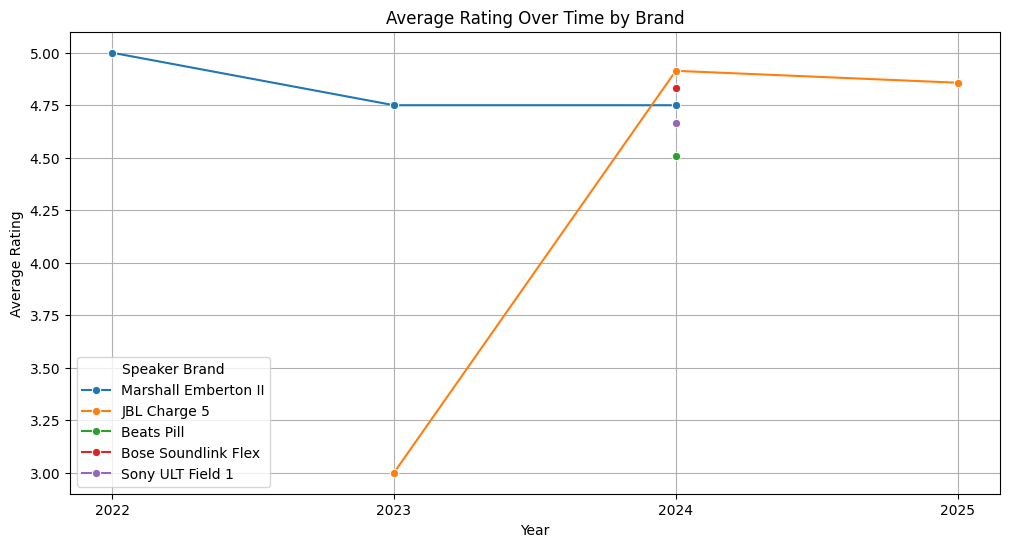

In [23]:
yearly_avg = products_df.groupby(['year', 'product_name'])['rating'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_avg, x='year', y='rating', hue='product_name', marker='o', palette='tab10')
plt.title('Average Rating Over Time by Brand')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.xticks(yearly_avg['year'].unique())
plt.legend(title='Speaker Brand')
plt.grid(True)

### Conclusions/Insights on Ratings Over Time:
- Can see that of the 5 speakers we have selected for analysis only the JBL Charge 5 and Marshall Emberton II have data for more than 2 years
- The JBL Charge has had an increase in positive reviews from 2023 to 2024 and stablised from 2024 to 2025.
- The Marshall Emberton remained somewhat stable with a slight drop off from 2023 to 2024 the other speakers are newer and even though they have a large number of reviews (except the Beats Pill which has around 50) their review are largely positive between 4.5-5.0 rating.

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'Beats Pill'),
  Text(1, 0, 'Bose Soundlink Flex'),
  Text(2, 0, 'JBL Charge 5'),
  Text(3, 0, 'Marshall Emberton II'),
  Text(4, 0, 'Sony ULT Field 1')])

<Figure size 1400x1000 with 0 Axes>

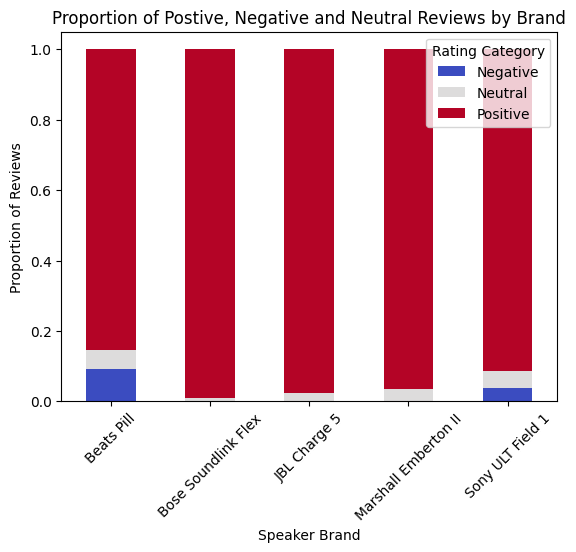

In [24]:
#positive, negaticw and neutral reviews by brand
def categorise_reviews(rating):
  if rating >= 4:
    return 'Positive'
  elif rating == 3:
    return 'Neutral'
  else:
    return 'Negative'

products_df['rating_category'] = products_df['rating'].apply(categorise_reviews)
rating_prop = products_df.groupby(['product_name', 'rating_category']).size().unstack(fill_value=0)
rating_prop = rating_prop.div(rating_prop.sum(axis=1), axis=0)

plt.figure(figsize=(14, 10))
rating_prop.plot(kind='bar', stacked=True, colormap='coolwarm')
plt.title('Proportion of Postive, Negative and Neutral Reviews by Brand')
plt.xlabel('Speaker Brand')
plt.ylabel('Proportion of Reviews')
plt.legend(title='Rating Category', loc='upper right')
plt.xticks(rotation=45)


### Conclusions/Insights on Positive, Negative and Neutral Review Distributions:
- Here we can see how people are generally satisfied with their wireless speakers overall.
- The Beats Pill has the highest proportion of negative reviews overall and the Charge 5 has the highest proportion of positive reviews overall.
- Beats and Sony have the most neutral customers.

/tmp/ipykernel_2706/316009391.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='product_name', y='rating', data=products_df, palette='Set3')


Text(0, 0.5, 'Rating Distribution')

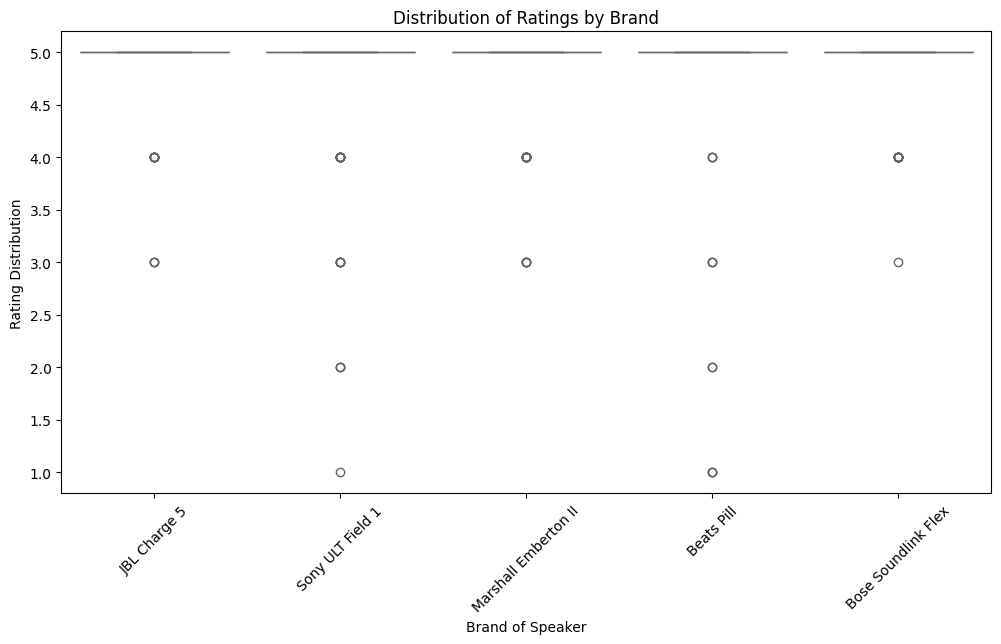

In [25]:
#distribution ratings by brand
plt.figure(figsize=(12, 6))

sns.boxplot(x='product_name', y='rating', data=products_df, palette='Set3')
plt.title('Distribution of Ratings by Brand')
plt.xticks(rotation=45)
plt.xlabel('Brand of Speaker')
plt.ylabel('Rating Distribution')

### Rating Distribution by Brand:
- Confirmed again that most reviews are positive.
- Reviews away from the highest ranking (5) are considered outliers in the box plot.
- Sony ULT and Beats Pill have the widest distribution of negative and positive ratings.
- **Reminder** Beats Pill has smallest rating sample size around 50 compared to other speakers which are around 100.

## Correlation Analysis:

In [26]:
products_df.head(1)

,review_id,title,author,rating,review,timestamp,profile_id,is_verified,helpful_count,product_attributes,product_name,review_lengths,review_date_clean,normalised_ratings,year,rating_category
16,R1V1VE2DAH2VT4,5.0 out of 5 stars Great sound and perfect gift,Daniel,5,I bought the JBL Charge 5 as a Christmas gift ...,"Reviewed in the United States March 26, 2025",AE6J7WB6CFUL4TXIJRZUKPNYFPAA,1,6,Color: Black,JBL Charge 5,238,2025-03-26,1.0,2025,Positive


In [27]:
num_cols = ['rating', 'review_lengths', 'helpful_count', 'year', 'normalised_ratings']
corr_matrix = products_df[num_cols].corr()
corr_matrix = corr_matrix.drop('normalised_ratings', axis=1)
corr_matrix = corr_matrix.drop('normalised_ratings', axis=0)
corr_matrix

,rating,review_lengths,helpful_count,year
rating,1.000000,-0.050794,0.027402,0.036769
review_lengths,-0.050794,1.000000,0.579136,-0.341040
helpful_count,0.027402,0.579136,1.000000,-0.422166
year,0.036769,-0.341040,-0.422166,1.000000


Text(0.5, 1.0, 'Correlation Matrix Heatmap')

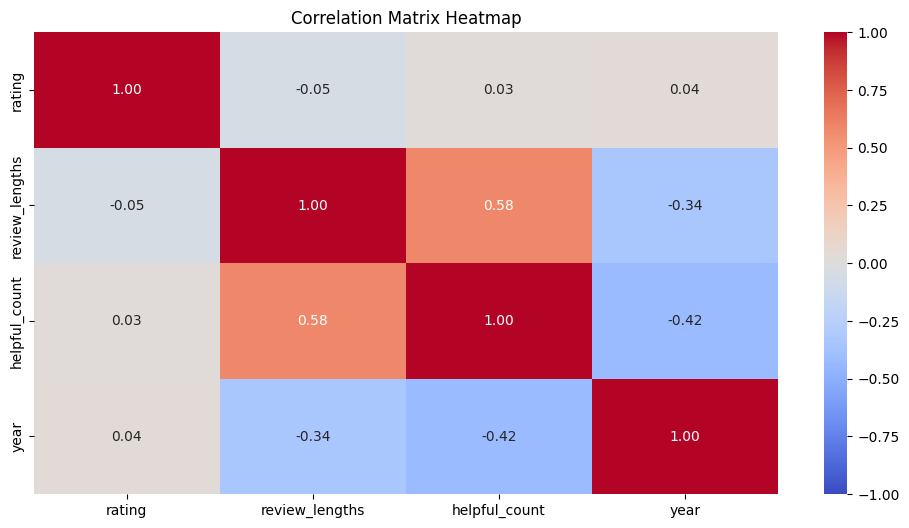

In [28]:
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap')

Text(0, 0.5, 'Helpful Count')

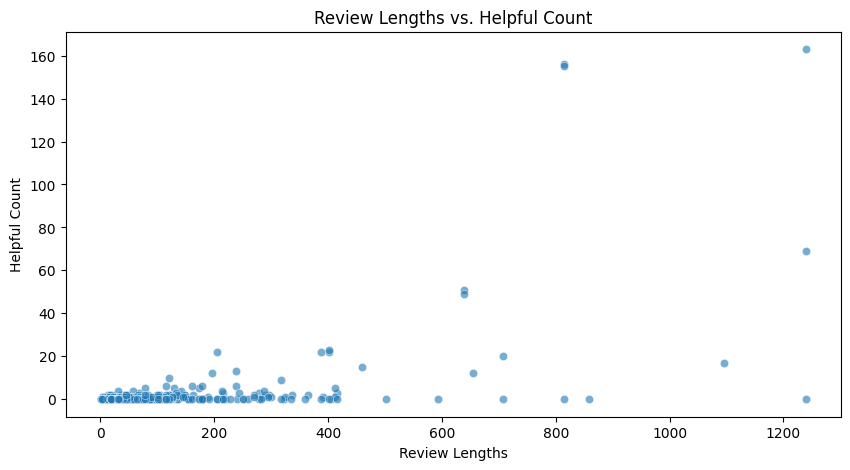

In [29]:
plt.figure(figsize=(10, 5))

sns.scatterplot(x='review_lengths', y='helpful_count', data=products_df, alpha=0.6)
plt.title('Review Lengths vs. Helpful Count')
plt.xlabel('Review Lengths')
plt.ylabel('Helpful Count')


In [30]:
corr_matrix.to_csv('corr_matrix.csv', index=True)

### Conclusions on Correlation Matrix and Heatmap:
- Can now see which hidden features are working together in terms of positivity and negativity.
- Interestingly helpful count/review lengths have the highest correlation coefficient (around 0.58) i.e. strongest positive correlation.
- Can see that reviews with shorter lengths tend to have a smaller number of helpful counts but the outliers (most likely negative reviews) have higher helpful counts.
- This is speculative but longer reviews may offer specific insight into a products short comings that may be helpful/important to new buyers entering the space.

## Text Analysis:

In [31]:
#reviewing a few individual sentences with textblob
blobs = [TextBlob(review) for review in products_df['review'].head().astype(str)]

for blob in blobs:
  print(f'Review: {blob}')
  print(f'Polarity: {blob.sentiment}\n')

Review: I bought the JBL Charge 5 as a Christmas gift for my partner, and it turned out to be the perfect choice. They’ve been using it nonstop ever since, and we’re both really impressed by how powerful and clear the sound is for such a compact speaker. The bass is strong without being overwhelming, and the mids and highs are crisp even at higher volumes. It’s loud enough to fill a room or even use outdoors without losing audio quality. We’ve used it for everything from morning podcasts to evening backyard hangouts, and it delivers every time.One of the standout features is the battery life. We easily get a full day’s use out of it, and the fact that it can charge other devices with the built-in powerbank feature is a huge bonus. It’s convenient not having to pack an extra charger when we’re on the go.Pairing is simple and fast with Bluetooth, and the JBL PartyBoost feature is great if you have more JBL speakers to link up for a bigger sound. We haven’t used that yet, but it’s nice to

In [32]:
#calculating polarity and subjectivity for all reviews
products_df['review_polarity'] = products_df['review'].apply(lambda x: TextBlob(x).sentiment.polarity)
products_df['review_subjectivity'] = products_df['review'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

products_df.head(3)




,review_id,title,author,rating,review,timestamp,profile_id,is_verified,helpful_count,product_attributes,product_name,review_lengths,review_date_clean,normalised_ratings,year,rating_category,review_polarity,review_subjectivity
16,R1V1VE2DAH2VT4,5.0 out of 5 stars Great sound and perfect gift,Daniel,5,I bought the JBL Charge 5 as a Christmas gift ...,"Reviewed in the United States March 26, 2025",AE6J7WB6CFUL4TXIJRZUKPNYFPAA,1,6,Color: Black,JBL Charge 5,238,2025-03-26,1.0,2025,Positive,0.337151,0.630284
17,R3AK5LLZ1VVTWJ,"5.0 out of 5 stars INSANE Speaker! Quality, vo...",Jeremy,5,The JBL Charge 5 is the BEST speaker I have ev...,"Reviewed in the United States April 5, 2024",AEDM32EKQE2HOHUCSXFF2Z27F7NQ,1,163,Color: Black,JBL Charge 5,1239,2024-04-05,1.0,2024,Positive,0.266337,0.507158
18,R3RKDJFQLNMHYE,5.0 out of 5 stars Overall an excellent produc...,Elizabeth A. Krause,5,we love the speaker! It works so well outside ...,"Reviewed in the United States February 16, 2025",AHWTB6LQVFEKQJKIYCZLEFIL5J3A,1,2,Color: Black,JBL Charge 5,99,2025-02-16,1.0,2025,Positive,0.342500,0.548452


Text(0, 0.5, 'Frequency at Polarity Score')

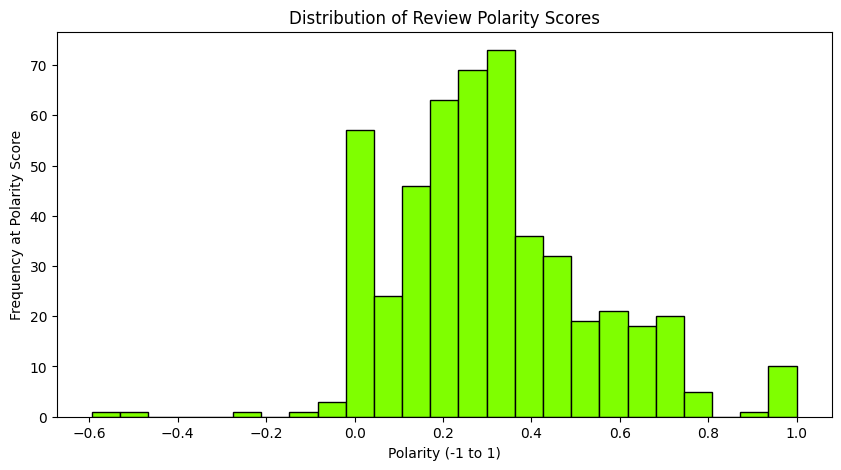

In [33]:
#histogram showing review polarity distribution
plt.figure(figsize=(10, 5))

plt.hist(products_df['review_polarity'], bins=25, color='chartreuse', edgecolor='black')
plt.title('Distribution of Review Polarity Scores')
plt.xlabel('Polarity (-1 to 1)')
plt.ylabel('Frequency at Polarity Score')


### Conclusions/Insights On Review Polarity:
- Can see that review polarity is positively skewed with the highest polarity frequency being between 0.2 and 0.4.
- Very few reviews have an extremely negative polarity which is good this indicates general satisfaction with wireless speakers as a whole and supports our earlier observations.

Text(0, 0.5, 'Review Subjectivity Score')

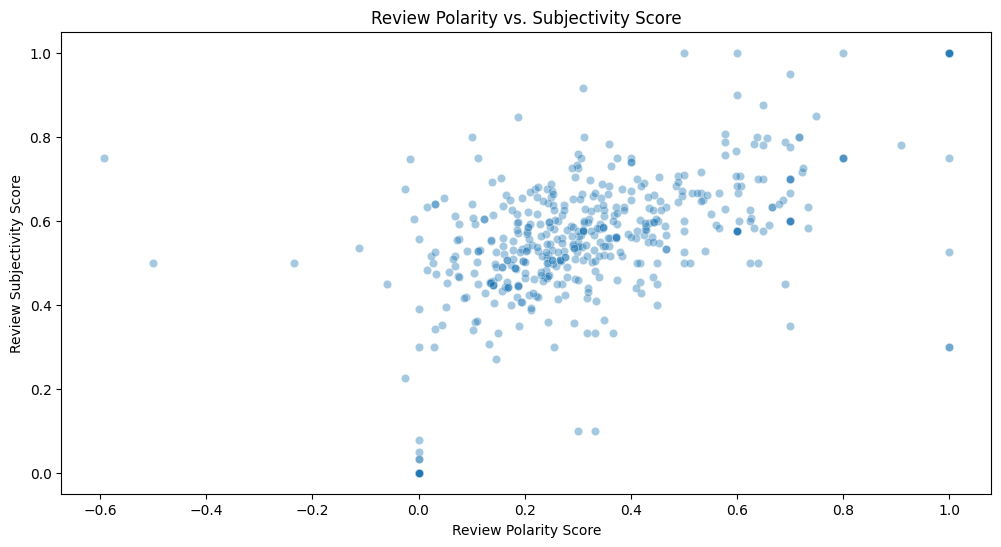

In [34]:
plt.figure(figsize=(12, 6))

sns.scatterplot(x='review_polarity', y='review_subjectivity', data=products_df, alpha=0.4)
plt.title('Review Polarity vs. Subjectivity Score')
plt.xlabel('Review Polarity Score')
plt.ylabel('Review Subjectivity Score')


### Conclusions/Insights On Polarity vs. Subjectivity
- Can see that the majority of review are average in terms of polarity and subjectivity.
- However extremely positive and extremely negative reviews tend to be more on the subjective side (likely a unique or localised issue with regards to negative reviews)
- This higher subjectivity is especially true for very positive reviews and again there are way more positive reviews than negative overall

In [35]:
def categorise_sentiment(polarity):
  if polarity > 0.2:
    return 'positive'
  elif polarity < -0.1:
    return 'negative'
  else:
    return 'neutral'

products_df['review_sentiment'] = products_df['review_polarity'].apply(categorise_sentiment)
products_df['review_sentiment'].value_counts()


,count
review_sentiment,
positive,338
neutral,159
negative,4


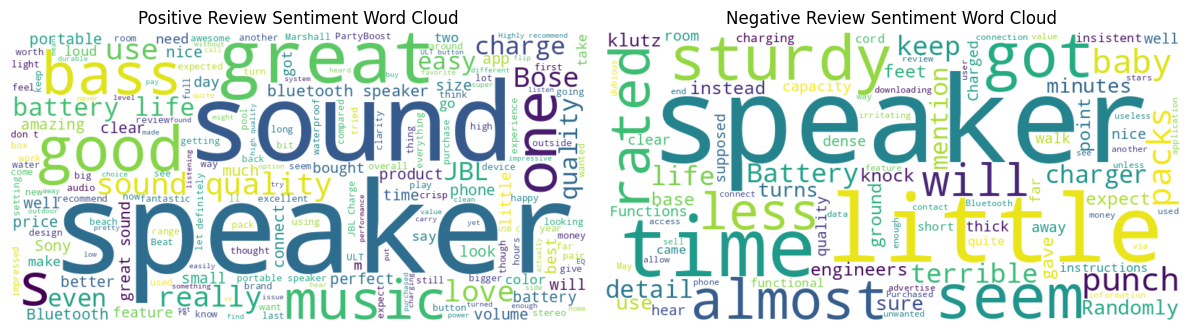

In [36]:
#wordcloud showing words associated with positive, negative and neutral review sentiments
pos_rev = " ".join(products_df[products_df['review_sentiment'] == 'positive']['review'])
pos_wc = WordCloud(background_color='white', width=800, height=400).generate(pos_rev)

neg_rev = " ".join(products_df[products_df['review_sentiment'] == 'negative']['review'])
neg_wc = WordCloud(background_color='white', width=800, height=400).generate(neg_rev)

fig, axs = plt.subplots(1, 2, figsize=(12, 10))

axs[0].imshow(pos_wc, interpolation='bilinear')
axs[0].set_title('Positive Review Sentiment Word Cloud', fontsize=12)
axs[0].axis('off')

axs[1].imshow(neg_wc, interpolation='bilinear')
axs[1].set_title('Negative Review Sentiment Word Cloud', fontsize=12)
axs[1].axis('off')

plt.tight_layout()


In [37]:
products_df.to_csv('products_df_with_sentiment.csv', index=False)

### Gemini Analysis:

In [40]:
#setting up gemini
def analyse_reviews(reviews, api_key, prompt_message):
  client = genai.Client(api_key=api_key)

  generation_config = {
      "temperature": 1,
      "top_p": 0.95,
      "top_k": 64,
      "max_output_tokens": 8192,
      "response_mime_type": "text/plain"
    }

  reviews_text = "\n".join(reviews)

  full_prompt = f"""
  {prompt_message}

  Reviews:
  {reviews_text}
  """
  response = client.models.generate_content(
      model="gemini-2.5-pro",
      contents=full_prompt,
      config=generation_config
    )

  return response.text

In [41]:
#getting the overall insights for the reviews on all speakers
from google.colab import userdata
reviews = products_df['review']
api_key = userdata.get('OPEN_API_KEY')
prompt = 'Analyse the following reviews and summarise the key insights:'

insights = analyse_reviews(reviews, api_key, prompt)
display(Markdown(insights))

Of course. Here is a detailed analysis and summary of the key insights from the provided reviews for the portable Bluetooth speakers.

### **Executive Summary**

The reviews cover several high-performing portable Bluetooth speakers, primarily the **JBL Charge 5**, **Sony ULT Field 1**, and **Marshall Emberton II**, with mentions of the **Bose SoundLink Flex** and **Beats Pill**. Overall, customers are extremely satisfied, highlighting that modern portable speakers offer impressive audio quality that far surpasses cheaper, generic alternatives.

The key differentiators lie in their sound profiles, unique features, and design philosophy:
*   **JBL Charge 5:** A powerful, durable, all-around performer with a standout battery/power bank feature.
*   **Sony ULT Field 1:** A rugged and highly portable speaker with a signature bass-boost button and a clever, functional design.
*   **Marshall Emberton II:** A style-focused speaker with excellent, detailed sound, but with significant caveats regarding placement and app functionality.
*   **Bose & Beats:** Strong contenders that appeal to users familiar with their respective brand's sound signature and ecosystem integration.

---

### **Overall Key Insights Across All Brands**

1.  **Impressive Sound Quality:** The most consistent theme is the "wow" factor of the audio quality. Users are blown away by the clarity, depth, and volume these compact speakers can produce, especially those upgrading from cheaper models.
2.  **Powerful Bass:** Modern portable speakers have mastered delivering strong, punchy bass that doesn't sound distorted or overwhelm the music, a feature praised across all reviewed models.
3.  **Excellent Battery Life:** Long-lasting battery is a major strength. Most speakers easily provide a full day of use on a single charge, making them reliable for outdoor activities and travel.
4.  **Durability is Standard:** Features like rugged builds, fabric coverings, and waterproofing (IP67 rating) are now expected and highly valued, allowing for worry-free use by the pool, at the beach, or in dusty environments.
5.  **Connectivity & Features are a Mixed Bag:** While basic Bluetooth pairing is seamless, advanced features like multi-speaker pairing (JBL's PartyBoost, Marshall's Stack Mode) can sometimes have connectivity issues or latency, especially for video. Companion apps are often a weak point, with limited functionality or buggy performance.

---

### **Detailed Summary by Speaker Model**

#### **1. JBL Charge 5: The Powerful All-Rounder**

The Charge 5 is consistently praised as a top-tier speaker that excels in almost every category, making it a reliable and versatile choice.

*   **Key Strengths:**
    *   **Exceptional Sound:** Described as "powerful," "stunningly clear," and "cinematic." It delivers strong, deep bass that is well-balanced with crisp mids and highs, even at high volumes. It's powerful enough to fill large rooms and outdoor spaces.
    *   **Outstanding Battery & Powerbank:** The long battery life is a major highlight, but the built-in power bank to charge other devices is seen as a game-changing bonus for portability and convenience.
    *   **Rugged and Durable:** With its fabric covering and waterproof design, users feel confident taking it anywhere.
    *   **Easy to Use:** Pairing is simple and fast.

*   **Key Weaknesses / Considerations:**
    *   **Minor Usability Issues:** The timing for the "skip track" button command (double-press play) can be finicky.
    *   **Portability:** Some find its "football shape" slightly bulky compared to more compact models.
    *   **PartyBoost Latency:** While the feature is appreciated for music, users note a significant audio delay when using it for watching videos.

*   **Best For:** Users seeking a powerful, reliable, do-it-all speaker for both indoor and outdoor use who value long battery life and the convenience of a built-in power bank.

#### **2. Sony ULT Field 1: The Rugged Bass-Booster**

This speaker is a strong competitor, praised for its ruggedness, portability, and signature sound-enhancing feature.

*   **Key Strengths:**
    *   **ULT Bass Boost:** The physical "ULT" button is its standout feature, providing a significant and noticeable boost to bass and overall sound, which users love for "hyping up" music.
    *   **Excellent Portability & Design:** It's lightweight, shockproof, and fully waterproof. The integrated carrying strap is a highly praised, surprisingly practical feature for hanging or carrying the speaker.
    *   **Great Sound Clarity:** Even with the bass boost, vocals and instruments remain clear and open, avoiding a tinny sound at high volumes.
    *   **Customisable Sound:** The companion app offers a 3-band EQ for users who want to fine-tune the audio.

*   **Key Weaknesses / Considerations:**
    *   **Default Sound:** Without the ULT button engaged, some might find the sound less impressive.
    *   **App Experience:** The app is functional but described as less polished than Sony's other applications.

*   **Best For:** Adventurous users who need a highly durable, portable speaker and enjoy a powerful, bass-forward sound that can be activated with a single button press.

#### **3. Marshall Emberton II: The Stylish Performer**

The Marshall speaker wins on aesthetics and detailed audio, appealing to users who value design as much as performance.

*   **Key Strengths:**
    *   **Iconic Design & Premium Feel:** The retro amplifier look is a major selling point. It's described as "stunning," "cool," and a "piece of art," making it a stylish home accessory.
    *   **Detailed and Rich Sound:** Users are impressed by its "dynamic," "sharp," and detailed stereo sound, which is achieved by front-and-back firing drivers. It excels at making vocals and instruments stand out.
    *   **Exceptional Battery Life:** It boasts a very long playtime, often lasting for days of casual use.

*   **Key Weaknesses / Considerations:**
    *   **Placement is Crucial:** Because of its 360° sound design, it cannot be placed against a wall without muffling one channel. It performs best in the center of a space.
    *   **Poor App Functionality:** The companion app is the most significant weak point, with users reporting frequent connectivity issues, failed firmware updates, and useless EQ presets.
    *   **Control Knob:** The single brass multifunction knob, while stylish, has invisible markings that can make it difficult to use initially.

*   **Best For:** The style-conscious user who wants a speaker that doubles as a design piece and delivers excellent, detailed audio for music, and is willing to overlook a poor app experience and specific placement requirements.

In [42]:
#analysing individual products and their feature performance
def analyse_indv_prods(reviews, product_name):
  prompt_message = f"""Analyse these reviews for {product_name}:
  1) What are the top 3 mentioned features?
  2) What do customers love about this product?
  3) What are the most common complaints?

  Please provide specific examples from the reviews."""

  return analyse_reviews(reviews, api_key, prompt_message)

In [43]:
speakers = ['JBL Charge 5', 'Sony ULT Field 1', 'Marshall Emberton II', 'Beats Pill', 'Bose Soundlink Flex']

results = {}

for speaker in speakers:
  product_reviews = products_df[products_df['product_name'] == speaker]['review'].tolist()[:30]
  speaker_insights = analyse_indv_prods(product_reviews, speaker)

  #time.sleep(1)
  results[speaker] = speaker_insights

In [44]:
for speaker, insight in results.items():
  md_text = f'##{speaker}\n\n{insight}'
  display(Markdown(md_text))

##JBL Charge 5

Of course. Here is a detailed analysis of the provided reviews for the JBL Charge 5.

### 1) What are the top 3 mentioned features?

Based on the frequency and emphasis in the reviews, the top three standout features are:

1.  **Exceptional Sound Quality (especially Bass):** This is the most praised aspect of the speaker. Reviewers consistently express surprise and satisfaction with the clarity, volume, and depth of the sound, particularly for a portable device.
    *   **Example:** "We’re both really impressed by how powerful and clear the sound is for such a compact speaker. The bass is strong without being overwhelming, and the mids and highs are crisp even at higher volumes."
    *   **Example:** "The clarity is absolutely stunning! The bass is DEEP. I can feel the bass through my whole room! The volume is insane."

2.  **Long Battery Life:** Customers highlight the speaker's ability to last for extended periods, often through a full day of use, which is crucial for its portable nature.
    *   **Example:** "One of the standout features is the battery life. We easily get a full day’s use out of it..."
    *   **Example:** "I once had the speaker provide some background noise for about two days and the battery life was barely lower than 70%."

3.  **Built-in Powerbank:** The ability to charge other devices is a defining feature of the "Charge" series and is repeatedly mentioned as a major convenience and bonus.
    *   **Example:** "...the fact that it can charge other devices with the built-in powerbank feature is a huge bonus. It’s convenient not having to pack an extra charger when we’re on the go."
    *   **Example:** "And the powerbank USB charge-out is a lifesaver! I can charge my phone on the go, which is super handy during long outings..."

### 2) What do customers love about this product?

Beyond specific features, customers love the overall package of performance, durability, and versatility.

*   **Powerful Sound from a Portable Size:** Users are consistently blown away by the volume and quality of audio that comes from a relatively compact speaker, often stating it exceeds their expectations.
    *   **Example:** "I didn't think I would get this much sound out of a small speaker."
    *   **Example:** "Watching movies with this speaker makes the entire experience cinematic! A much bigger upgrade compared to the sound TV’s come with."

*   **Durability and Ruggedness:** Customers appreciate that they can use the speaker in various environments (pool, beach, workshop) without worrying about damage from water or dust.
    *   **Example:** "The waterproof feature is a game-changer too. I’ve taken it to the pool and the beach, and it’s held up perfectly fine even after getting splashed."
    *   **Example:** "I’ve dropped it in water with no effect, no connection problems, easy to use. Very durable."

*   **Ease of Use and Connectivity:** The simplicity of pairing the speaker via Bluetooth is frequently praised, allowing users to start playing music within seconds.
    *   **Example:** "Pairing is simple and fast with Bluetooth..."
    *   **Example:** "I literally turned it on, saw it appear on my BlueTooth, connected and started playing music in 10 sec."

*   **Versatility:** They love that it's a go-to device for any situation, from providing background music while cleaning to being the centerpiece of a backyard hangout or a gym session.
    *   **Example:** "We’ve used it for everything from morning podcasts to evening backyard hangouts, and it delivers every time."
    *   **Example:** "This is the perfect little system to enjoy music out on my patio, while I’m gardening, or in my wood shop."

### 3) What are the most common complaints?

Complaints are infrequent and relatively minor, but a few patterns emerge:

1.  **Size and Portability:** While it's a portable speaker, some users find it larger or heavier than they expected, which can be a slight drawback compared to smaller models.
    *   **Example:** "Although, it isn’t the most portable of portable speakers as it is a little big and has a football shape."
    *   **Example:** "It’s a bit on the heavier side, but considering the sound quality and battery life, it’s a trade-off I’m happy to make."
    *   **Example:** "Bigger than expected, sounds quality is perfect."

2.  **Minor Technical Glitches:** A few users reported isolated technical issues, such as connectivity problems or control quirks.
    *   **Example:** "For the skip feature, you have to press the play/pause button twice... If you do it too fast it will just pause. If you do it too slow, it will just pause then play again."
    *   **Example:** "I've only owned my JBL Charge 5 for a few days, but it already started making random crackling sounds... Update: Installed the latest firmware... and have not heard any crackling sounds from the speaker lately."

3.  **PartyBoost Latency with Video:** One detailed review points out a significant audio delay (latency) when using the PartyBoost feature to link multiple speakers for watching videos, making it unsuitable for that specific use case.
    *   **Example:** "...please note there IS some lag between sound and video, as bluetooth will do... In addition to standard bluetooth latency, PartyBoost will make this delay greater (I ended up returning the other two because of this issue)."

##Sony ULT Field 1

Of course. Based on the provided reviews, here is a detailed analysis of the Sony ULT Field 1 speaker.

### 1) What are the top 3 mentioned features?

The most frequently and enthusiastically mentioned features are the ULT sound button, the carrying strap, and the speaker's waterproof and durable build.

1.  **The ULT Button:** This is the most prominent feature discussed. It's a physical button that provides a significant, one-press boost to the audio, primarily enhancing bass and overall presence.
    *   **Example:** "The ULT button adds a lot of bass and I love that! It is great for EDM, Hip hop, R&B..."
    *   **Example:** "This 'ULT' button packs a punch... gives you more bass - check, and the other sounds also get enhanced. It’s pretty remarkable."
    *   **Example:** "...the physical ULT button provided great boost to your music by itself to hype up any outdoor event."

2.  **The Carrying Strap:** Reviewers were surprisingly impressed by the simple but highly functional carrying strap. They highlight its versatility for both carrying and hanging the speaker in various locations.
    *   **Example:** "The strap is genius! It can tighten or loosen and then stay in place. My little one liked to carry it around like a purse..."
    *   **Example:** "Strap - It allows me to hang the speaker on the patio umbrella and out of the way of things (see pic)."
    *   **Example:** "The included carrying strap is a nice touch that... I find myself carrying the speaker solely by the strap anywhere I take it."

3.  **Waterproofing and Durability:** Customers frequently mention the speaker's ruggedness and resistance to water and dirt, which gives them confidence to use it in various environments like showers, pools, and beaches.
    *   **Example:** "Ok, so I like music in the shower, and let me tell you... this thing delivers, even when it got wet it still sounded clear."
    *   **Example:** "That is when I discovered it could float!! Now it does not sound great that way, but it still played even after multiple 'accidental' dunks in the tub!"
    *   **Example:** "As expected, it dropped into the stinky pond muck... after fishing it out, I rinsed it off with some dawn and the water hose and it was good as new."

---

### 2) What do customers love about this product?

Beyond specific features, customers love the speaker's overall sound quality for its size, its practical and thoughtful design, and its excellent value for the price.

*   **Impressive Sound Quality:** The most common point of praise is the powerful and clear audio that comes from such a compact device. Reviewers feel it sounds "bigger than it looks" and often outperforms competitors.
    *   **Example:** "As to no surprise from this being from Sony, this speaker sounds amazing. It doesn’t get tinny at higher volumes, the dual drivers create amazing bass..."
    *   **Example:** "The sound is very open, clear on vocals, it fills up a big room really well... sony simply just outperforms [the JBL Flip 6]!"
    *   **Example:** "The sound is gorgeous. The bass is clear and deep... for music fans without those funds... this is the one."

*   **Functional and Versatile Design:** Customers appreciate the smart design choices that make the speaker easy to use anywhere. This includes its ability to stand vertically or horizontally without blocking the sound, its lightweight build, and the clever strap.
    *   **Example:** "You can use it horizontal like normal or when you stand it vertically, the bottom speaker isn’t fully covered. The air can go somewhere."
    *   **Example:** "It can seamlessly stand or sit facing you or directly up to disperse the sound evenly."
    *   **Example:** "The design is killer... super easy to connect with my iPhone."

*   **Excellent Value:** Many reviewers explicitly state that the speaker is well worth its price, offering performance and build quality that competes with or exceeds more expensive options.
    *   **Example:** "While it is certainly understandable to hesitant when looking at a $120 Bluetooth speaker, this one truly is worth its value."
    *   **Example:** "On sale : $98, i would buy it IMMEDIATELY:), insane value."
    *   **Example:** "Not a Bose flex link. But good for the price."

---

### 3) What are the most common complaints?

The reviews are overwhelmingly positive, so complaints are minor and less frequent. However, two points of criticism emerge:

1.  **ULT Sound Can Be Muffled or Overpowering:** While most love the ULT button, a couple of users noted that it can negatively affect sound clarity, particularly with vocals, or be too aggressive for the small speaker.
    *   **Example:** "ULT setting is a bit muffled. Base is good. Voice highs are a little low in the ULT settling."
    *   **Example:** "...my only issue is that when you turn the Ult on it can have a chance of blowing out your speaker... I recommend using it while the u l t is turned off and just put it to custom..."

2.  **Limited Maximum Volume:** A few reviewers mentioned that while the speaker is loud enough for most situations, it may not be sufficient for very large outdoor spaces or for listening to quieter audio like podcasts.
    *   **Example:** "At max volume, while the speaker does not get deafening loud if you are outdoors... it certain gets loud enough to entertain a large area."
    *   **Example:** "My issue is that it only turns up a little with my phone and tablet. If I'm listening to a talk and the person has a quiet voice, I can't hear clearly."

##Marshall Emberton II

Of course, here is an analysis of the reviews for the Marshall Emberton II.

### 1) What are the top 3 mentioned features?

Based on the frequency and emphasis in the reviews, the top three most mentioned features are its sound quality, distinctive design, and portability.

1.  **Sound Quality:** Nearly every review comments on the impressive, rich, and powerful sound that comes from such a small device. It's often highlighted for its balanced audio and strong bass.
    *   **Example:** "Don’t be fooled by its size; the Emberton packs a punch. With two 10W drivers, it delivers a surprisingly rich and dynamic sound. The bass is deep and satisfying, the mids are clear, and the highs are crisp."
    *   **Example:** "This is not your typical tinny speaker box, this is a micro boom box."

2.  **Design & Aesthetics:** The iconic, retro look modeled after Marshall's classic guitar amplifiers is a major selling point. Customers consistently praise its appearance, build quality, and nostalgic feel.
    *   **Example:** "The iconic Marshall logo adorns the front, paying homage to the brand’s heritage."
    *   **Example:** "Using the nostalgia factor with the Marshall amplifier design was a touch of genius, and the brass button on top is the cherry on top."

3.  **Portability & Compact Size:** The speaker's small footprint and light weight are frequently mentioned as key advantages, making it easy to carry and travel with.
    *   **Example:** "The Emberton’s compact size, weighing just 0.7 kilograms, makes it incredibly portable. Slip it into your bag or pocket, and you have a powerful sound system wherever you go."
    *   **Example:** "Really glad I didn't get the larger one which would no doubt sound great but would not be small enough to take it anywhere."

### 2) What do customers love about this product?

Customers primarily love the combination of powerful, high-quality audio in a stylish and portable package.

*   **Powerful Sound in a Small Form Factor:** The most common point of praise is the speaker's ability to produce a sound that seems too big for its size.
    *   **Example:** "It defies its size, delivering a sound quality that rivals much larger speakers."
    *   **Example:** "I can't believe the sound from a small box. Highly recommend!"

*   **The Iconic "Cool Factor":** The classic Marshall design is a significant reason for purchase and satisfaction. It's seen as a stylish accessory, not just a piece of tech.
    *   **Example:** "The look and feel of this speaker is just superior!"
    *   **Example:** "Got a couple a compliments on how the speaker looks."

*   **Ease of Use (Physical Controls):** Many users appreciate the simple, intuitive multi-directional brass control knob for power, volume, and track skipping.
    *   **Example:** "If we can handle touch control on over-head and in-ear speakers, this button is a piece of cake."
    *   **Example:** "Easy to use. Pairs well. Great size. Love it so much!"

*   **Impressive Battery Life (When It Meets Expectations):** Several reviews confirm the long-lasting battery, which adds to its convenience and portability.
    *   **Example:** "The battery lasting up to 30 hours is impressive."
    *   **Example:** "It's got great sound and the battery life last a long time!"

### 3) What are the most common complaints?

The most common complaints center around the dysfunctional mobile app, the battery life not living up to the 30-hour claim under real-world use, and sound limitations at high volumes.

1.  **The Mobile App is Useless:** This is the most consistent and strongly-worded complaint. Users report that the app fails to connect to the speaker, offers very limited features (like a basic 3-band EQ), and often doesn't work at all.
    *   **Example:** "The app is useless. I guess I expected something from the app. I’m at a loss for the point of it. It continued so say my phone Bluetooth was not on. Even as I was literally playing music through it."
    *   **Example:** "the application takes forever to actually 'discover' the device, even when it is already paired."

2.  **Battery Life Doesn't Meet the 30-Hour Claim:** While some praise the battery, a common complaint is that the advertised 30 hours is only achievable at low volumes. At moderate to high volumes, the battery drains much faster.
    *   **Example:** "It’s good, but it does not hold the 30 hours with good sound volume."
    *   **Example:** "My battery runs down to like 40% after playing @ 85% vol for about 4 hours, so not to bad imho." (This implies a total life of around 7-8 hours at high volume, far from 30).

3.  **Sound Issues at High Volume:** Reviewers note that the speaker's performance suffers at its maximum volume, with some experiencing distortion or a "frazzled" sound. Others feel the maximum volume isn't loud enough for certain situations.
    *   **Example:** "...as long as you don’t play loudly, at that point the music will frazzle out. So limited, not surprising."
    *   **Example:** "I get distortion when the vol is max."
    *   **Example:** "The sound is crisp, but the volume is not loud enough."

4.  **Minor Design Flaws:** While the overall design is loved, a few users pointed out that the function labels around the control knob are nearly impossible to see.
    *   **Example:** "...the signs indicating the functions around the button, being carved in the black speaker... are for all intent and purposes invisible."

##Beats Pill

Of course. Here is an analysis of the provided reviews for the new Beats Pill.

### 1) What are the top 3 mentioned features?

Based on the frequency and emphasis in the reviews, the top three mentioned features are:

1.  **Sound Quality:** This is the most discussed aspect of the speaker. Customers consistently comment on the clear, balanced audio and surprisingly powerful bass for the speaker's compact size.
    *   **Example:** "The sound quality of this speaker is really great for its size, living up to the Beats name, filling the room with punchy bass and crystal clear sound."
    *   **Example:** "I was blown away by the balanced sound for all genre of music. Bass is well balanced with Treble and does not try to be more than what a small speaker can do."

2.  **Design and Portability:** The physical look, feel, and size of the speaker are frequently highlighted. Reviewers appreciate its premium build, stylish appearance, and how easy it is to carry.
    *   **Example:** "Speaker has a nice heft to it and the design of the speaker is really nice, with the angled design, and the speakers facing you."
    *   **Example:** "It's small, stylish, and easy to carry around, which is perfect for when I'm on the go."

3.  **Seamless Apple Ecosystem Integration:** For iPhone users, the easy pairing and integration with other Apple services is a major selling point. This includes the initial setup, device switching, and features like "Find My."
    *   **Example:** "If you are in the Apple Ecosystem, this speaker was made for you as it connects to your iPhone the minute you turn it on with a very satisfying screen animation."
    *   **Example:** "Also if your in the apple eco system it works like AirPods where you can switch between devices and also locate the speaker via find my."

### 2) What do customers love about this product?

Customers love the combination of premium feel, powerful sound, and smart functionality, making it feel like a high-value product.

*   **Impressive Sound for its Size:** Users are consistently surprised and pleased by the audio performance, often comparing it favorably to larger or more expensive speakers.
    *   **Example:** "This 2 pound speaker sounds insane for its size. It’s almost as loud as my jbl Xtreme 2."
    *   **Example:** "In fact it sounds much better than my Sonos Roam 2 and JBL Flip 6, which the latter I’ve always considered a good sounding speaker."

*   **Premium Build and Design:** The quality of the materials and the aesthetic are major positives, making the speaker feel sturdy and look good in any setting.
    *   **Example:** "The unboxing experience and the design of the speaker is quintessentially Apple."
    *   **Example:** "Great product, also very sturdy it survived a drop with only a little cosmetic damage."

*   **Versatile Functionality:** Beyond just playing music, users love the extra features that enhance its utility, such as the speakerphone for calls and the ability to listen to lossless audio via USB-C.
    *   **Example:** "But what sets this speaker apart... is that it also doubles as a speakerphone!!! I can connect this badboy to my laptop, and take crystal clear Teams calls with it all day at work."
    *   **Example:** "You can even hook it up via usb c to get lossless music."

*   **Excellent Battery Life:** The claimed 24-hour battery life is a significant point of praise, adding to its convenience and portability.
    *   **Example:** "Battery life of this thing is stated at a whopping 24 hrs... if true, is completely mind blowing."
    *   **Example:** "The sound is great for the size and the battery life is great!"

### 3) What are the most common complaints?

The complaints focus on limitations in software control and degraded performance under specific conditions.

1.  **Lack of a Dedicated App with EQ Control:** A recurring complaint is the absence of a mobile app to adjust settings, specifically the equalizer (EQ), to customize the sound profile.
    *   **Example:** "The only downside is that there isn't an app to control the speaker. It would be nice to have an app to adjust settings, check battery life, and manage connections."
    *   **Example:** "...pill doesn't have an eq in its app at all...."

2.  **Sound Distortion at High Volumes:** While the sound is praised at low to medium volumes, several users noted that the bass becomes distorted or "muddy" when the volume is turned up high.
    *   **Example:** "However at above 50% the bass becomes muddy, it has this weird flutter sound to it."
    *   **Example:** "Too much bass and voice distorts on full Volume."

3.  **Poor Microphone Performance for Calls and Voice Assistants:** Despite being praised as a feature, the speakerphone's real-world performance is a point of frustration for some, requiring users to be very close to the device for calls or using Siri.
    *   **Example:** "...the call I had to shout lol it needs a up date"
    *   **Example:** "If you try to use Siri, you have to be right next to the speaker... if you’re cooking... and the speaker is on the other side of the room it won’t work because she won’t be able to hear you."

##Bose Soundlink Flex

Of course. Here is an analysis of the provided reviews for the Bose Soundlink Flex.

### 1) What are the top 3 mentioned features?

Based on the frequency and detail in the reviews, the top three most mentioned features are:

1.  **Sound Quality (Especially Bass):** This is the most dominant theme. Nearly every review comments on the speaker's audio performance, often expressing surprise at the quality from such a small device.
    *   **Examples:** "The sound is crisp and clear, and I love the bass levels; when that bass kicks in, it becomes a full-on party!" and "Being a Bose I expected good sound but this blew past my expectations when it came to bass and clarity."

2.  **Battery Life & Voice Prompts:** Customers frequently mention the battery's longevity and, specifically, the helpful voice prompt feature that announces the remaining charge and connected devices upon startup.
    *   **Examples:** "It holds a charge a long time! And it announces each time it’s turned on how much charge is left. No guessing." and "I love how it lets me know how much charge I have remaining and which device it connects to when I turn it on."

3.  **Portability & Durability:** The speaker's compact size, water resistance, and robust build are key features highlighted by users who take it to various locations.
    *   **Examples:** "I appreciate that it is water resistant as I take this into the bathroom, the kitchen, camping, etc." and "The loop on the side makes it possible to hang the speaker easily too. That’s especially helpful outside on the porch."

### 2) What do customers love about this product?

Beyond specific features, customers love the overall experience and value the speaker provides.

*   **Exceptional Sound from a Small Package:** The most common point of delight is the powerful, high-quality sound that comes from a compact and portable speaker. It consistently exceeds expectations.
    *   **Example:** "What’s not to like about this speaker. Great sound in a small package. The highs and lows air outstanding... For the size, this is outstanding."

*   **Ease of Use and Convenience:** Users appreciate how simple the speaker is to operate, from pairing with their phones to its straightforward controls and helpful notifications.
    *   **Example:** "This one has the best sound of all my speakers, easy use buttons, easy to set-up. Has automatic shut-off, which is a plus in my book."

*   **Versatility:** Customers love that they can use the speaker in a wide variety of settings—from the shower and kitchen to outdoor locations like the beach, boat, or by a fire pit.
    *   **Example:** "I use it 2x a day in the shower as well as on my back sun porch." and "Mainly I bought it for out on my boat. I can hear the radio even when my 90 4 stroke is full throttle."

*   **The Bose Brand Reputation:** Several reviewers mention their long-term trust in the Bose brand for quality and longevity, which adds to their satisfaction with the purchase.
    *   **Example:** "You always pay more, but the quality and workmanship you can’t deny….they are just amazing and last forever, to me that is worth a lot."

### 3) What are the most common complaints?

While overwhelmingly positive, the reviews highlight a few recurring issues and annoyances.

1.  **Connectivity & Setup with Computers:** The most detailed complaint involves difficulty connecting the speaker to a desktop computer. Unlike other Bluetooth devices, it doesn't always automatically set itself as the sound output, requiring manual configuration in the system settings.
    *   **Example:** "You may have trouble getting this to play sound from you desktop computer... For some reason this Bose unit doesn't default as the output as other Bluetooth speakers did on my computer."

2.  **Inconsistent Battery Life:** While many praise the battery, a few users had a very negative experience, suggesting potential quality control issues or that the battery life doesn't meet everyone's expectations.
    *   **Example:** "Used it for 2 hours... Went to use it today (3 days later) and the battery is at 30%. The battery 🪫 life on this speaker SUCKS!!!!" Another user simply stated, "I wish the battery lasted longer."

3.  **Minor Design and Accessory Issues:** Several smaller complaints were mentioned across different reviews:
    *   **Material Attracts Debris:** "The material that it's made of is messy. It picks up dust and dog hair way too easily."
    *   **Short Charging Cable:** "The only downside is the charging cable is too short; I just used a different cord."
    *   **Annoying Voice Prompts:** While many love this feature, some find it irritating, though they note it can be turned off. "It was always saying the speaker disconnected even though it was still playing. The app let me turn off the voice prompts."

In [45]:
#sentiment analysis with gemini
def analyse_sentiment_patterns(reviews, review_sentiment, product_name):
  prompt_message = f"""Analyze these {review_sentiment.lower()} reviews for {product_name}:
    1. What specific aspects create {review_sentiment.lower()} reactions?
    2. Identify common phrases or descriptions used
    3. Note any comparisons with competitor products
    4. Find unexpected or unique feedback

    Support your analysis with specific examples."""

  return analyse_reviews(reviews, api_key, prompt_message)

In [46]:
sent_results = {}

for speaker in speakers:
  positive_revs = products_df[(products_df['product_name'] == speaker) & (products_df['review_sentiment'] == 'positive')]['review'].tolist()[:30]
  pos_sent_insights = analyse_sentiment_patterns(positive_revs, 'positive', speaker)

  sent_results[speaker] = pos_sent_insights

In [47]:
for speaker, sent_insight in sent_results.items():
  md_text_sent = f'##{speaker}\n\n{sent_insight}'
  display(Markdown(md_text_sent))

##JBL Charge 5

Of course. Here is a detailed analysis of the positive reviews for the JBL Charge 5, supported by specific examples.

### 1. What specific aspects create positive reactions?

The reviews consistently highlight a core set of features that drive customer satisfaction. The most praised aspects are sound quality, battery performance, and durability, which combine to create a versatile and high-performing speaker.

*   **Exceptional Sound Quality:** This is the most frequently mentioned positive attribute. Reviewers are impressed by the power and balance of the audio, especially for a portable speaker.
    *   **Clarity and Balance:** "The sound is great and very clear. There is a good level of base and clarity." and "The mids and highs are crisp even at higher volumes."
    *   **Powerful Bass:** The bass is a standout feature, described as strong but not muddy. "The bass is strong without being overwhelming," and "The bass is DEEP. I can feel the bass through my whole room!"
    *   **High Volume without Distortion:** Users are surprised by its ability to fill large spaces. "It’s loud enough to fill a room or even use outdoors without losing audio quality," and "I once had music filling a whole event center that was quite a reasonable size."

*   **Long-Lasting Battery Life:** The speaker's endurance is a major selling point, allowing for extended use without needing a recharge.
    *   **All-Day Performance:** "We easily get a full day’s use out of it," and "The charge lasts pretty much all day so taking it outside is very nice."
    *   **Impressive Longevity at Low Volume:** "I once had the speaker provide some background noise for about two days and the battery life was barely lower than 70%."

*   **Durability and Ruggedness:** The waterproof and sturdy design gives users confidence to take the speaker anywhere.
    *   **Waterproof Confidence:** "I’ve dropped it in water with no effect," and "I love that I don’t have to worry if it gets wet or dusty."
    *   **Solid Build Quality:** "It feels solid and durable, which is exactly what you need in a portable speaker," and "clearly built to last."

*   **The Built-in Power Bank:** This "charge out" feature is seen as a significant and convenient bonus.
    *   **Practical Convenience:** "The fact that it can charge other devices... is a huge bonus. It’s convenient not having to pack an extra charger when we’re on the go."
    *   **A "Lifesaver":** "And the powerbank USB charge-out is a lifesaver! I can charge my phone on the go, which is super handy."

*   **Ease of Use and Connectivity:** Simple, fast Bluetooth pairing makes the speaker accessible to everyone.
    *   **Quick Setup:** "Pairing is simple and fast with Bluetooth," and "I had it up and running in minutes."

### 2. Identify common phrases or descriptions used

Certain words and phrases appear repeatedly, forming a consensus on the speaker's key strengths.

*   **Describing Sound:** The most common descriptors are **"clear and crisp,"** **"deep bass,"** **"punchy bass,"** and **"powerful sound."**
*   **Describing Volume:** Reviewers often use words like **"insane volume,"** **"fills the room,"** and **"BIG sound."**
*   **Overall Impression:** Phrases like **"BEST speaker I have ever owned,"** **"highly recommend,"** **"worth every penny,"** and **"get what you pay for"** are used to express high satisfaction and brand loyalty.
*   **Brand Loyalty Statements:** Many reviews conclude with statements like **"Only buying JBL speakers from now on"** and **"I believe we will stay with this brand."**

### 3. Note any comparisons with competitor products

Reviewers often validate their purchase by comparing the Charge 5 to competitors, particularly Bose, as well as cheaper generic speakers and even other models within the JBL lineup.

*   **Direct Comparison to Bose:** The JBL Charge 5 is often chosen over Bose for its superior bass.
    *   **Example 1:** "Bought the Bose sound link and this one to compare... I ended up keeping the JBL charge 5. It was on sale for a great price and had a **more punchy bass compared to the Bose sound link.**"
    *   **Example 2:** "I'm coming from owning a Bose Soundlink Revolve... I honestly think the **JBL has better sound at higher volume than the Bose Revolve.**"
    *   **Example 3:** A reviewer notes that a friend's older JBL "Charge 3 blew my Bose speaker away."

*   **Comparison to Cheaper/Generic Speakers:** The Charge 5 is framed as a significant upgrade that reveals the shortcomings of budget options.
    *   **Example:** "I have had the average run-of-the-mill bluetooth speaker that has around a $20 value... I thought it was good sound quality... I only had one thought as I played music out of it for the first time. **WOW!**"

*   **Comparison within the JBL Product Line:** One user provides a nuanced comparison between different JBL models, highlighting the Charge 5's balanced position.
    *   **Example:** "I first bought the JBL Pulse 5... Then I bought the JBL Flip 6... the **JBL Charge 5 is the best choice for me in terms of portability, and sound.** It's got a really nice full sound, and I don't have to turn it up quite as loud as the JBL Flip 6 to achieve the full sound I like."

### 4. Find unexpected or unique feedback

Beyond the standard praise, some reviews offer unique use cases, detailed technical observations, and vivid sensory descriptions.

*   **Use as a Makeshift Soundbar:** One reviewer uses the speaker as the primary audio source for their projector, enhancing their movie-watching experience.
    *   **Example:** "I currently use this speaker with a projector to watch TV... Watching movies with this speaker makes the **entire experience cinematic!** A much bigger upgrade compared to the sound TV’s come with."

*   **Physical Sensation of Power:** A user describes a tangible effect of the speaker's output that goes beyond just hearing the sound.
    *   **Example:** "When I turn it to high volumes, **I can actually feel air blowing from it!**"

*   **Detailed Critique of PartyBoost Latency:** The same reviewer who uses it for their projector provides specific, valuable feedback on the limitations of PartyBoost for video.
    *   **Example:** "please note there IS some lag between sound and video... **PartyBoost will make this delay greater** (I ended up returning the other two because of this issue). For music, this is not a problem."

*   **Specific Button Functionality Quirk:** A minor but very specific piece of feedback concerns the timing needed to skip a track.
    *   **Example:** "For the skip feature, you have to press the play/pause button twice... If you do it too fast it will just pause. If you do it too slow, it will just pause then play again."

*   **Appreciation for Subtle Design Details:** A review goes beyond general aesthetics to praise specific material choices.
    *   **Example:** "I love the fabric covering. **The JBL logo is made of metal, which makes it look very nice and official.**"

##Sony ULT Field 1

Of course. Here is a detailed analysis of the positive reviews for the Sony ULT Field 1, supported by specific examples from the text.

### 1. Specific Aspects Creating Positive Reactions

The positive reactions are driven by a combination of exceptional sound quality for its size, a robust and thoughtful physical design, and a strong feature set that adds tangible value.

*   **Powerful and Customizable Sound:** The most praised aspect is the sound quality, particularly the bass performance, which users feel is disproportionate to the speaker's compact size.
    *   **Example:** "It sounds way bigger than it looks. The ULT button adds a lot of bass and I love that!"
    *   **Example:** "The sound quality has really good range from the low tones to the high tones... I am very impressed of the sound reproduction of this speaker."

*   **The "ULT" Button:** This physical button for bass boost is a standout feature that users frequently mention and appreciate for its immediate impact.
    *   **Example:** "The ULT button is a feature I find myself using more than expected... to help boost my music during gatherings."
    *   **Example:** "Once you press that, it really amps up the bass while not sacrificing the clarity of the vocals."

*   **Robust Durability and Waterproofing:** Users feel confident using the speaker in harsh environments, citing its rugged build and effective waterproofing. The reviews contain vivid, real-world durability tests.
    *   **Example:** "As expected, it dropped into the stinky pond muck... after fishing it out, I rinsed it off with some dawn and the water hose and it was good as new."
    *   **Example:** "That is when I discovered it could float!! Now it does not sound great that way, but it still played even after multiple 'accidental' dunks in the tub!"

*   **Smart and Versatile Design:** The physical design, including the shape and the carrying strap, is highly praised for its practicality and versatility.
    *   **Example:** "The strap is genius! It can tighten or loosen and then stay in place. My little one liked to carry it around like a purse."
    *   **Example:** "The hourglass shape is great for palming it... The speaker can seamlessly stand or sit facing you or directly up to disperse the sound evenly."

*   **Strong Battery Life and Connectivity:** The speaker meets or exceeds expectations for battery longevity and provides a simple, stable Bluetooth connection.
    *   **Example:** "I’ve gone 6 hours of using the speaker which left it at 50%, so I believe their claim of 12 hours of battery life to be true."
    *   **Example:** "Bluetooth connection is swift, taking about 3 seconds from pressing the power button to streaming audio from your connected device."

### 2. Common Phrases or Descriptions Used

Certain phrases and descriptive terms appear repeatedly, painting a consistent picture of the user experience.

*   **On Sound:** "Packs a punch," "sounds bigger than it looks," "fills the room," "clear," "crisp," and "amazing bass."
*   **On the ULT Feature:** "Great boost," "amps up the bass," "a whole new ball park," and "unleashing the Iron Giant."
*   **On Build & Design:** "Rugged," "high quality," "versatile," "compact," and "functional."
*   **On the Strap:** "Genius," "nice touch," and "versatile."
*   **On Value:** "Worth its value," "insane value," and "bang for the buck."

### 3. Comparisons with Competitor Products

The reviews frequently position the ULT Field 1 as superior to established competitors, primarily from JBL and Bose.

*   **JBL (Flip and Charge series):** The Sony speaker is directly compared and favored over JBL's popular models for having a more open and less harsh sound.
    *   **Example:** "My Go-to was always the JBL flip series... And i found myself reaching for the field 1! It sounds better, its more open... as for the JBL, it targets the sound directly at you, and the highs are a bit harsh, sony simply just outperforms it!"
    *   **Example:** "Doing a Hz test next to one of my Charge 5’s... The Sony produced noticeably more vibration than the Charge 5, which blew my mind."

*   **Bose, UE Boom, Beats Pill:** In broader comparisons, reviewers who have owned multiple brands declare the Sony speaker the winner in sound quality.
    *   **Example:** After retiring a "trusty Bose mini sound link 2," a reviewer found the Sony had "unbelievably great bass" and was a clear winner over "the UE boom, Bose sound link flex or Beats Pill I had previously tried."
    *   **Example:** "This SONY beats ALL of them!!! BOSE soundlink revolve 2 plus, BOSE minilink, JBL Charge5 and Flip6."

### 4. Unexpected or Unique Feedback

Beyond standard feature praise, reviewers highlighted several small details and surprising discoveries that enhanced their experience.

*   **"Stink Proof" Durability:** One of the most unique pieces of feedback was its ability to survive being submerged in "stinky pond muck" and be cleaned off with soap and water without any lingering smell or damage.

*   **It Floats:** A reviewer discovered by accident during a child's bath time that the speaker can float, adding an unexpected layer to its water-resistance.
    *   **Example:** "That is when I discovered it could float!!... it still played even after multiple 'accidental' dunks in the tub!"

*   **Subtle Design Details:** Small aesthetic choices were noticed and appreciated.
    *   **Example:** "The SONY logo on the front looks silver most of the time but actually has some... I don't know what, but it changes color, which is a nice touch."

*   **Appreciation for Minor Usability Features:** A user pointed out a seemingly minor but highly appreciated design choice for the power button.
    *   **Example:** "To power on/off this device, only a single press of the power button is needed for each. While a small detail, it truly is something that is appreciated for ease of use."

*   **Accidental Discovery of Speakerphone Functionality:** One user was pleasantly surprised to find out it worked as a speakerphone when they received a call.
    *   **Example:** "There have been a couple of times when my phone was paired to the speaker and somebody called in and I had a conversation with them not knowing I can actually talk to them from the speaker!"

##Marshall Emberton II

Of course. Here is a detailed analysis of the positive reviews for the Marshall Emberton II, broken down by your four key questions.

### 1. What specific aspects create positive reactions?

The positive reactions stem from a combination of four key attributes: the surprisingly powerful sound from a small device, the iconic and premium design, its portability, and its ease of use.

*   **Sound Quality for its Size:** This is the most frequently praised aspect. Reviewers are consistently impressed that such a small speaker can produce rich, full, and distortion-free audio.
    *   **Example:** "Don’t be fooled by its size; the Emberton packs a punch. With two 10W drivers, it delivers a surprisingly rich and dynamic sound."
    *   **Example:** "Great sound from surprisingly compact unit. Full, dynamic sound you can feel. This is not your typical tinny speaker box, this is a micro boom box."
    *   **Example:** "I’m really impressed that the sound quality is this good for this price and this size."

*   **Iconic Design and Build Quality:** The classic Marshall amplifier aesthetic is a major selling point. Users love the look, feel, and nostalgia associated with the brand, viewing it as a stylish accessory in addition to a speaker.
    *   **Example:** "It seamlessly blends timeless design with cutting-edge technology... The iconic Marshall logo adorns the front, paying homage to the brand’s heritage."
    *   **Example:** "Yes, the external design of this speaker is awesome with the black and gold design bringing back memories of yesteryear.........No only does this speaker look cool, it rocks out!"
    *   **Example:** "The look and feel of this speaker is just superior!"

*   **Portability and Convenience:** Its small footprint and light weight are highlighted as key benefits for travel and everyday carry.
    *   **Example:** "The Emberton’s compact size, weighing just 0.7 kilograms, makes it incredibly portable. Slip it into your bag or pocket..."
    *   **Example:** "It's easy to pack and we take it almost everywhere."
    *   **Example:** "Easy to carry for travel."

*   **Battery Life and Ease of Use:** While there are some nuanced comments, the battery life is generally seen as a positive, and its simple operation is appreciated.
    *   **Example:** "battery life is long. Excellent buy all around."
    *   **Example:** "I use it everyday, battery lasts a really long time without recharding..."
    *   **Example:** "Easy to use. Pairs well. Great size."

### 2. Identify common phrases or descriptions used

Certain descriptive words and phrases appear repeatedly, forming a consensus on the speaker's core identity.

*   **"For its size" / "Small box" / "Compact":** This qualifier is almost always used when discussing sound quality, emphasizing the impressive audio-to-size ratio.
    *   **Examples:** "Packs great sound for its size," "a lot of sound for a small box," "amazed me the sound it produced with such a small footprint."

*   **"Packs a punch" / "Little powerhouse":** These phrases are used to describe the speaker's unexpected power and volume.
    *   **Example:** "save time and get this little powerhouse, Marshall."

*   **"Great sound" / "Amazing sound" / "Exceptional sound":** These general but enthusiastic descriptors are the most common way users summarize their satisfaction with the audio.
    *   **Example:** "The sound is amazing! It even has bass."

*   **"Looks great" / "Awesome looking" / "Attractive":** Simple, direct praise for the visual design.
    *   **Example:** "Doesn’t hurt that it’s so attractive either."

*   **"Rich" / "Dynamic" / "Full" / "Crisp":** These words are used to provide more specific detail about the balanced and high-quality nature of the sound.
    *   **Example:** "The bass is deep and satisfying, the mids are clear, and the highs are crisp, offering a well-balanced audio experience."

### 3. Note any comparisons with competitor products

Reviewers frequently compare the Emberton II to other well-known brands, often positioning it as superior in sound fidelity and design.

*   **Favorable Comparisons (JBL, Bose, Altec, Jambox):** The Emberton II is often declared the winner against major competitors, particularly in terms of sound clarity and balanced bass.
    *   **Example:** "This Bluetooth is head an shoulders above any JBL, Altec, or Bose Bluetooth speaker I've yet heard. The bass while strong, is not ridiculous, and muffled."
    *   **Example:** "I have had lots of small speakers (Bose, Jambox, etc) and this one sounds the best!"

*   **A Specific Concession to JBL:** One review provides a nuanced comparison, admitting a JBL speaker is louder, which makes it better for parties, even while praising the Marshall's look and daily-use sound.
    *   **Example:** "I bought the charge 4 from jbl three years ago... the volume isn’t as loud as one would think. But if you’re looking to throw a little party... I would recommend a different option."
    *   **Example:** "This has 20w (JBL - has 40w) but this looks great and for the room it is enough."

### 4. Find unexpected or unique feedback

Beyond the common themes, several reviews offered unique perspectives, specific details, and practical advice.

*   **The "Damaged Box" Hack:** One user shared a specific money-saving tip, which is unique and practical feedback.
    *   **Example:** "Bought this speaker at a discount on Amazon from the damaged box store. Box was lightly damaged. Item inside was in perfect condition. Saved a boat load of cash doing so."

*   **Highly Specific Audio Praise:** A standout comment went beyond "good bass" to identify a very specific element of audio fidelity that impressed them.
    *   **Example:** "What blew my mind is that I could hear the snare on a drum! No Bluetooth speaker I've had before could make a snare drum sound right."

*   **The "Stacking" Aspiration:** One review playfully referenced the speaker's amp design in a unique way.
    *   **Example:** "Its awesome looking as being addicted to concerts :P When I get the chance, I will stack them lol!"

*   **Critiques on Battery and App:** While overwhelmingly positive, some unique feedback pointed out specific flaws, providing a more balanced view.
    *   **Example (Battery):** "The battery often does not remain charged and sometimes as soon as I unplug it from the charger I will lose one bar of battery."
    *   **Example (App):** "Would give it 5 stars, but the app doesn't work. Hopefully they will get that fixed soon."

*   **Tactile Sensation:** A review described the physical feel of the speaker in a very detailed and sensory way.
    *   **Example:** "Very pleasant to the touch - on the outside it is covered with a kind of soft and pleasant rubber that hugs the skin."

##Beats Pill

Of course. Here is a detailed analysis of the positive reviews for the new Beats Pill, broken down by the requested categories and supported by specific examples.

### 1. Specific Aspects Creating Positive Reactions

The positive reactions stem from a combination of excellent audio performance for its size, seamless integration with the Apple ecosystem, premium design, and versatile features that go beyond just music playback.

*   **Sound Quality (Especially Bass and Clarity):** The most frequently praised aspect is the speaker's ability to produce rich, powerful sound from a compact device. Reviewers are impressed by the balance between strong bass and clear vocals.
    *   **Example:** "The sound quality of this speaker is really great for its size... filling the room with punchy bass and crystal clear sound."
    *   **Example:** "I was blown away by the balanced sound for all genre of music. Bass is well balanced with Treble and does not try to be more than what a small speaker can do."

*   **Apple Ecosystem Integration:** For iPhone users, the setup and multi-device functionality are major selling points, mirroring the user-friendly experience of other Apple products like AirPods.
    *   **Example:** "If you are in the Apple Ecosystem, this speaker was made for you as it connects to your iPhone the minute you turn it on with a very satisfying screen animation."
    *   **Example:** "...it works like AirPods where you can switch between devices and also locate the speaker via find my."

*   **Design and Build Quality:** The physical look and feel of the speaker receive high marks for being both aesthetically pleasing and durable.
    *   **Example:** "Speaker has a nice heft to it and the design of the speaker is really nice, with the angled design, and the speakers facing you."
    *   **Example:** "This is definitely the best-looking and sleekest portable speaker. It’s minimal, smooth, and easy to carry around."
    *   **Example:** "...very sturdy it survived a drop with only a little cosmetic damage."

*   **Versatile Functionality:** Features beyond simple Bluetooth music playback, like the speakerphone and USB-C audio, are highlighted as significant value-adds.
    *   **Example:** "But what sets this speaker apart... is that it also doubles as a speakerphone!!! I can connect this badboy to my laptop, and take crystal clear Teams calls with it all day at work."
    *   **Example:** "You can even hook it up via usb c to get lossless music."
    *   **Example:** "Pretty cool how it can charge your phone and vice versa."

*   **Long Battery Life:** The advertised 24-hour battery life is a key feature that impresses reviewers, even if they haven't fully tested it.
    *   **Example:** "Battery life of this thing is stated at a whopping 24 hrs. I'll definitely be testing that claim, but if true, is completely mind blowing."

### 2. Common Phrases or Descriptions Used

Several phrases and descriptive terms appear repeatedly across the reviews, painting a consistent picture of the product's strengths.

*   **"For its size":** This qualifier is used frequently to emphasize the impressive power and quality coming from such a small device.
    *   **Example:** "The sound quality of this speaker is really great for its size..."
    *   **Example:** "This speaker has incredible sound and bass for its size."

*   **"Punchy Bass" / "Great Bass" / "Deep Base":** Variations of this are almost universal, indicating that the low-end audio performance is a defining characteristic.
    *   **Example:** "...filling the room with punchy bass..."
    *   **Example:** "It delivers good, deep base..."

*   **"Crystal Clear Sound" / "Clear Vocals":** This is often paired with the bass description to show the sound is not just powerful but also well-balanced and detailed.
    *   **Example:** "...punchy bass and crystal clear sound."
    *   **Example:** "The audio is crystal clear, with balanced mids and highs."

*   **"Easy to connect" / "Seamless":** Describes the user-friendly Bluetooth pairing process, especially for Apple and Android users.
    *   **Example:** "...connecting it to my devices with Bluetooth is super easy."
    *   **Example:** "Sounds fantastic with no connection issues."

*   **"Stylish" / "Sleek" / "Quintessentially Apple":** These terms are used to describe the premium and minimalist design aesthetic.
    *   **Example:** "The new Pill features a stylish, everything-proof design."
    *   **Example:** "...the unboxing experience and the design of the speaker is quintessentially Apple."

### 3. Comparisons with Competitor Products

Reviewers frequently compare the Beats Pill to other popular portable speakers, and in most of these positive reviews, the Pill comes out on top.

*   **JBL (Flip 6 and Charge 5):** The Pill is consistently rated as superior or a "more complete package" than the JBL Flip 6.
    *   **Example:** "In fact it sounds much better than my Sonos Roam 2 and JBL Flip 6..."
    *   **Example:** "It's comparable to the JBL Flip 6... but this more complete package for its price..."

*   **Bose, B&O, and Sonos:** The Pill is seen as a strong competitor, even against more expensive or established brands in the space.
    *   **Example:** "I own several portable speakers, Bose, JBL, and these are my favorite."
    *   **Example:** "I was currently using the B&O Bluetooth speaker which is really good and is a bit more money... Compared to all of them this is an amazing speaker for the price point."

*   **Soundcore and Wonderboom:** The Pill is cited as a clear upgrade or a better choice.
    *   **Example:** "Returned the soundcore motion 300 for this one."
    *   **Example:** "My original Wonderboom finally gave up so I bought the Beats Pill. I was blown away by the balanced sound..."

*   **Negative Comparison (Outlier):** One reviewer, while generally positive, offered a direct negative comparison, which is valuable for context.
    *   **Example:** "Too much bass and voice distorts on full Volume. I find Earfun Uboom L is better."

### 4. Unexpected or Unique Feedback

Beyond the common praises, some reviewers offered unique insights or highlighted less-obvious benefits.

*   **Primary Use as a Work Speakerphone:** The most unique feedback was using the Pill as a primary device for work calls, not just for music. This positions it as a professional tool as well as a leisure device.
    *   **Example:** "I can connect this badboy to my laptop, and take crystal clear Teams calls with it all day at work. And when I'm done with my calls... I can listen to lossless music..."

*   **Praise Despite Disliking Other Beats Products:** One reviewer’s positive reaction was strengthened by their previous negative experiences with other Beats headphones, suggesting the Pill is an exceptionally well-made product for the brand.
    *   **Example:** "Note I have also tried both of the newest beats over ear headphones and hated them, so I was surprised that this was as good as it is."

*   **Specifics on Sound Distortion:** A highly detailed review, while positive, gave a very specific and honest critique about performance at high volumes, which is unique feedback.
    *   **Example:** "The biggest critique I have is that it’s the worst-sounding speaker if you go above 80% volume. The distortion and fuzzy sound are awful... The best volume range I found is 30%-70%..."

*   **Lossless Audio via USB-C:** While mentioned by a couple of reviewers, the ability to get lossless audio through a wired USB-C connection is a high-fidelity feature that is unexpected for a typical portable Bluetooth speaker.
    *   **Example:** "...since it is connected to my laptop via USB-C, I can listen to lossless music on Apple Music. Mind...blown!"

##Bose Soundlink Flex

Of course. Here is a detailed analysis of the positive reviews for the Bose Soundlink Flex, supported by specific examples.

### 1. What specific aspects create positive reactions?

The positive reactions stem from a combination of core performance features, thoughtful design elements, and brand trust.

*   **Superior Sound Quality (Especially Bass and Clarity):** This is the most frequently praised aspect. Users are consistently impressed by the power and richness of the sound coming from a small device.
    *   **Example:** "The sound is crisp and clear, and I love the bass levels; when that bass kicks in, it becomes a full-on party!"
    *   **Example:** "Being a Bose I expected good sound but this blew past my expectations when it came to bass and clarity."
    *   **Example:** "The highs and lows air outstanding... For the size, this is outstanding."

*   **Portability and Form Factor:** The speaker's size, combined with features like the utility loop, makes it highly versatile for both indoor and outdoor use.
    *   **Example:** "The loop on the side makes it possible to hang the speaker easily too. That’s especially helpful outside on the porch..."
    *   **Example:** "It’s the perfect size for desktop, counter, and luggage space."

*   **Ease of Use and Connectivity:** Users appreciate the straightforward and quick Bluetooth pairing process.
    *   **Example:** "I had no problem connecting my phone and my MacBook Air to the Bose app... the connection is flawless!"
    *   **Example:** "It was easy to pair it to my phone and to pair up the second speaker. Just follow the instructions provided!"

*   **Durability and Build Quality:** The materials and waterproof features give customers confidence in the speaker's longevity, especially for outdoor activities.
    *   **Example:** "I like the rubber cover because I use them outside a lot!"
    *   **Example:** "Gotten it wet with no issue."
    *   **Example:** "You can just feel it in the weight of the item. It's solid."

*   **Battery Life and Charging:** The long-lasting charge and quick charging time are significant convenience factors. The voice prompt for battery level is also a frequently mentioned positive.
    *   **Example:** "It holds a charge for quite some time. I love how it lets me know how much charge I have remaining..."
    *   **Example:** "The battery charges fast, and it stays charged for days of use."

*   **Aesthetics and Color Options:** The availability of appealing colors allows the speaker to be a personal accessory, not just a piece of tech.
    *   **Example:** "The color is perfect, as it fits all of my periwinkle/lavender color schemes."
    *   **Example:** "I got it in the green and it has woodsy vibes."

### 2. Identify common phrases or descriptions used

Certain words and phrases appear repeatedly, forming a consensus on the speaker's key attributes.

*   **"Sound is amazing/great/awesome":** This or a very similar phrase is the most common starting point for praise.
    *   **Example:** "The sound is amazing!"
    *   **Example:** "This tiny speaker sounds amazing! Very impressed."

*   **"Crisp and clear":** Used specifically to describe the audio fidelity, separating it from just being loud.
    *   **Example:** "The sound is crisp and clear, and I love the bass levels..."
    *   **Example:** "The clear and crisp audio (and waterproofness) make this a great speaker to use in the shower!"

*   **"Great Bass":** The power of the low-end frequencies is a standout feature mentioned in numerous reviews.
    *   **Example:** "I was ecstatic when I plugged it in and heard how awesome the bass is..."
    *   **Example:** "This speaker packs great sound, especially base."

*   **"For the size" / "Small package/unit":** This qualifier is frequently used to emphasize how impressive the sound is relative to the speaker's compact dimensions.
    *   **Example:** "Great sound in a small package."
    *   **Example:** "These are the best little speakers with a huge sound that I have ever had!"

*   **"Easy to connect/pair":** This highlights the user-friendly setup.
    *   **Example:** "Pairing this speaker with my phone was easy."
    *   **Example:** "This speaker was easy to connect to phone etc and works great."

*   **"It's a BOSE!":** This phrase or sentiment shows up often, indicating that the product meets or exceeds the high expectations associated with the brand name.
    *   **Example:** "But then….it’s a BOSE!!!!"
    *   **Example:** "I trust Bose!"

### 3. Note any comparisons with competitor products

Direct comparisons to specific, named competitors are limited, but users frequently compare the Soundlink Flex to older speakers they've owned, including previous Bose models.

*   **Direct Competitor Mention:** One user explicitly weighed their options against a popular rival.
    *   **Example:** "Toggled between JBL and Bose (both would have been a good choice)."

*   **Comparison to a Previous Bose Model:** The Flex is seen as a significant upgrade over its predecessors.
    *   **Example:** "I bought this one to replace my Bose soundlink color 2 speaker... It has waaaaaay better sound quality than the soundlink color 2 model!"

*   **Comparison to Unnamed/Generic Speakers:** The Flex is consistently framed as being in a different league than other Bluetooth speakers the reviewers have owned.
    *   **Example:** "I've had other bluetooth speakers that were pretty good, but... When I play it, then stop and play my other bluetooth speaker, there's really no comparison. The Bose has significantly better base, and extremely clear tones."

### 4. Find unexpected or unique feedback

Beyond the standard praise, several reviews offered unique use cases, insightful critiques, and specific technical observations.

*   **Unique Professional and Hobbyist Use Cases:**
    *   **Massage Therapy:** "This is a fun product and also use it for my massage work it really is a handy tool as well."
    *   **On a Boat:** "Mainly I bought it for out on my boat. I can hear the radio even when my 90 4 stroke is full throttle."
    *   **In a Tractor:** "I got this for my husband, as his tractor's radio quit working."
    *   **Mounted on a Motorcycle:** "I mounted to my motorcycle (with padded foam just in case.) So far no major problems."

*   **Insightful Technical Observation:** One user noted the clever real-world benefit of its waterproof rating.
    *   **Example:** "I like that it has a good IP rating. Waterproof also means dust proof, so we can use this at the motocross track."

*   **A Specific Negative Point (within a positive review):** A user pointed out a design flaw related to the material.
    *   **Example:** "But the material that it's made of is messy. It picks up dust and dog hair way too easily. I am trying to find a good way to keep it clean."

*   **Workaround for a Common Annoyance:** One reviewer provided a helpful tip for disabling the voice prompts without needing the app.
    *   **Example:** "The app let me turn off the voice prompts. Then I found the actual user manual online and discovered an alternate method: Press and hold + and - simultaneously until you hear 'Voice prompts off.'"

*   **Thoughtful Mono vs. Stereo Consideration:** A user addressed the potential downside of a single speaker being mono and concluded it wasn't an issue due to the sound quality.
    *   **Example:** "I initially wondered if I would miss stereo sound... In any case, the sound quality that comes out is full and rich including low-end... the listening experience through this speaker is beautiful."

In [48]:
def analyse_comparative_reviews(reviews_dict):
  products_list = ", ".join(reviews_dict.keys())

  prompt_message = f"""Compare customer feedback across these products: {products_list}
  For each product, analyze:
  1. Standout features and unique selling points
  2. Common complaints or limitations
  3. Price-to-value perception
  4. Target user preferences

  Then compare:
  1. Key differences in customer satisfaction
  2. Feature preferences across products
  3. Quality and reliability mentions

  Format as a structured comparison with specific examples."""

  combined_revs = []

  for product, reviews in reviews_dict.items():
    labeled_revs = [f'[{product}] {review}' for review in reviews]
    combined_revs.extend(labeled_revs[:20])

  return analyse_reviews(combined_revs, api_key, prompt_message)



In [49]:
products_to_compare = ['JBL Charge 5', 'Beats Pill']
reviews_dict = {}
for product in products_to_compare:
  reviews = products_df[products_df['product_name'] == product]['review'].tolist()[:20]
  reviews_dict[product] = reviews

comparison_insights = analyse_comparative_reviews(reviews_dict)
display(Markdown(comparison_insights))

Of course. Here is a structured comparison of customer feedback for the JBL Charge 5 and the Beats Pill, based on the provided reviews.

***

### **Part 1: Individual Product Analysis**

#### **JBL Charge 5**

**1. Standout Features and Unique Selling Points**
Customers consistently praise the JBL Charge 5 for its core speaker performance and practical utility features.

*   **Powerful, High-Quality Sound:** This is the most frequently mentioned highlight. Users describe the sound as "powerful and clear," with "stunning" clarity and "deep" bass that is "strong without being overwhelming." One reviewer notes they can "feel the bass through my whole room," and another says it makes their movie-watching experience "cinematic."
*   **Exceptional Battery Life:** The long battery life is a major selling point. Reviewers are impressed, with one stating, "We easily get a full day’s use out of it," and another noting that after providing "background noise for about two days," the battery was still above 60%.
*   **Built-in Powerbank:** The ability to charge other devices is a highly valued convenience feature. It's frequently described as a "huge bonus" and a "lifesaver" for charging phones on the go.
*   **Durability and Rugged Design:** The speaker's build quality inspires confidence. Users call it "solid and durable" and "built to last." The waterproof feature is a "game-changer," with one customer confirming they "dropped it in water with no effect."

**2. Common Complaints or Limitations**
While overwhelmingly positive, the reviews mention a few minor drawbacks.

*   **Portability:** Some users find its size and shape a bit cumbersome for maximum portability. One review calls it "a little big and has a football shape," suggesting it's not as easy to carry as smaller speakers. Another notes it's "a bit on the heavier side."
*   **Finicky Controls:** A specific complaint is the control for skipping tracks, which requires a double-press of the play/pause button. One user details the difficulty: "If you do it too fast it will just pause. If you do it too slow, it will just pause then play again."
*   **PartyBoost Latency:** While the PartyBoost feature is seen as a good option for music, one user who tried to create a surround sound system for their TV found the audio lag (latency) was too significant, stating, "PartyBoost will make this delay greater."
*   **Connectivity Issues (Isolated):** One reviewer experienced "random crackling sounds" shortly after purchase but resolved it with a firmware update via the JBL app.

**3. Price-to-Value Perception**
The JBL Charge 5 is perceived as a premium product that is worth its cost.

*   **Example:** Reviewers acknowledge it is "a little pricey" but immediately follow up by saying, "you get what you pay for!" and "it’s a trade-off I’m happy to make."
*   **Sales Value:** Catching it on sale is seen as a "very good deal," reinforcing that its value proposition is strong, especially at a discount.

**4. Target User Preferences**
The feedback suggests the JBL Charge 5 is ideal for users who:
*   Prioritize raw sound performance, high volume, and strong bass.
*   Need a versatile speaker for both indoor and outdoor use (backyard, pool, beach, workshop).
*   Value long battery life and the convenience of a built-in powerbank.
*   Require a durable, waterproof device that can withstand an active lifestyle.

---

#### **Beats Pill**

**1. Standout Features and Unique Selling Points**
Customer praise for the Beats Pill centers on its sound quality, design, and seamless integration with the Apple ecosystem.

*   **Apple Ecosystem Integration:** This is a key differentiator. Users love that it "connects to your iPhone the minute you turn it on," similar to AirPods. The ability to use Apple's "Find My" to locate the speaker is also a significant plus.
*   **Speakerphone Functionality:** The built-in microphone for taking calls is a major advantage for many. One user was thrilled that it "doubles as a speakerphone," allowing them to "take crystal clear Teams calls with it all day at work."
*   **Balanced and High-Quality Sound:** The sound is described as "crystal clear," "well balanced," and having "punchy bass." Multiple reviewers state it sounds better than competitors like the JBL Flip 6 and Sonos Roam 2, especially at lower volumes where it maintains "details in the notes that definitely sound high-fi."
*   **USB-C Audio and Charging:** The ability to listen to lossless music via a USB-C connection to a laptop is a unique feature highlighted by one reviewer. The versatility to "charge your phone and vice versa" is also praised.

**2. Common Complaints or Limitations**
The limitations noted by users are primarily related to software and performance at high volumes.

*   **No Dedicated App:** A recurring complaint is the lack of an app. One reviewer stated, "The only downside is that there isn't an app to control the speaker. It would be nice to have an app to adjust settings, check battery life, and manage connections."
*   **Sound Degradation at High Volume:** One direct comparison noted a performance drop at higher volumes: "at above 50% the bass becomes muddy, it has this weird flutter sound to it," whereas the JBL Flip 6 did not.
*   **Less Powerful than Larger Speakers:** A user who owns both brands explicitly states that while it competes with the smaller JBL Flip 6, it "Definitely not" compete with the larger JBL Charge 5, acknowledging it has smaller woofers.

**3. Price-to-Value Perception**
The Beats Pill is seen as providing excellent value, with its premium feel and features justifying the price.

*   **Example:** Reviewers call it an "amazing speaker for the price point" and "very worth the price."
*   **Premium Feel:** One customer notes, "The controls feel premium," contributing to the perception of a high-value product.

**4. Target User Preferences**
The feedback indicates the Beats Pill is best suited for users who:
*   Are heavily invested in the Apple ecosystem and value seamless connectivity and features like "Find My."
*   Need a speaker that doubles as a high-quality speakerphone for work or personal calls.
*   Appreciate a sleek, "quintessentially Apple" design.
*   Prefer a clear, balanced sound profile, particularly for listening at moderate volumes.

***

### **Part 2: Direct Comparison**

**1. Key Differences in Customer Satisfaction**
*   **JBL Charge 5 Satisfaction:** Comes from its raw power, reliability, and functional ruggedness. Customers are happy because it's a workhorse speaker that delivers loud, bass-heavy sound anywhere, for a very long time, and can even charge their phone. Satisfaction is rooted in *core performance and utility*.
*   **Beats Pill Satisfaction:** Comes from its smart features, convenience, and refined sound at moderate levels. Customers are happy with how effortlessly it integrates into their digital life (especially Apple users), its dual-functionality as a speakerphone, and its premium design. Satisfaction is rooted in *ecosystem integration and smart convenience*.

**2. Feature Preferences Across Products**
Customer reviews highlight a clear divergence in what features are most valued in each product.
*   **JBL Users Prefer:**
    *   **Powerbank:** Mentioned repeatedly as a "lifesaver."
    *   **PartyBoost:** Valued by those wanting to expand their sound system for parties, even with its limitations.
    *   **Waterproofing/Durability:** A key reason for purchase for outdoor and active use.
*   **Beats Users Prefer:**
    *   **Apple Integration:** The "AirPods-like" pairing and "Find My" feature are killer apps for iPhone users.
    *   **Speakerphone:** A highly practical feature for those who work from home or take frequent calls.
    *   **USB-C Audio:** A niche but appreciated feature for audiophiles wanting lossless playback from a computer.

**3. Quality and Reliability Mentions**
Both speakers are perceived as high-quality, but the nature of the praise differs.
*   **JBL Charge 5:** Quality is associated with **physical resilience**. Words like "durable," "solid," "rugged," and "built to last" are common. Its ability to survive drops in water is cited as direct proof of its reliability.
*   **Beats Pill:** Quality is associated with **premium design and build**. Reviewers mention its "nice heft," "premium controls," and "sturdy" feel. One user confirmed its durability, noting it "survived a drop with only a little cosmetic damage." The reliability is also linked to its flawless software integration with Apple devices.

In [50]:
#analysing specific features
def analyse_features(reviews, feature_name, product_name):
  prompt_message = f"""Analyze mentions of {feature_name} in these reviews:
  1. How do customers describe the {feature_name}?
  2. What specific aspects are praised or criticized?
  3. How does {feature_name} compare across products?
  4. What improvements do customers suggest?

  Include specific quotes and examples."""

  return analyse_reviews(reviews, api_key, prompt_message)

In [51]:
features = ['Battery Life', 'Sound Quality', 'Portability']

feature_results = {}
for speaker in speakers:
  reviews = products_df[products_df['product_name'] == speaker]['review'].tolist()[:30]

  feature_results[speaker] = {}

  for feature in features:
    comp_insights = analyse_features(reviews, feature, speaker)
    feature_results[speaker][feature] = comp_insights
    time.sleep(1)

In [52]:
for speaker, features_dict in feature_results.items():
  display(Markdown(f"##{speaker}"))

  for feature, insight in features_dict.items():
    display(Markdown(f"###{feature}\n\n{insight}"))

##JBL Charge 5

###Battery Life

Of course. Here is a detailed analysis of the mentions of Battery Life in the provided reviews.

### 1. How do customers describe the Battery Life?

Customers overwhelmingly describe the battery life of the JBL Charge 5 in positive and superlative terms. It is consistently highlighted as a major strength and a key feature of the product.

Common descriptions include:
*   **Long-lasting and reliable:** Users frequently mention that the speaker lasts "all day" or for extended periods without needing a recharge.
*   **Excellent and Perfect:** The performance is often rated highly, with one user giving it a "10/10 Perfect!" score.
*   **A Standout Feature:** Several reviews point to the battery life as one of the most impressive aspects of the speaker.

**Specific Quotes:**
*   "One of the standout features is the battery life. We easily get a full day’s use out of it..."
*   "...the battery life on this thing is long!"
*   "BATTERY: 10/10 Perfect! I absolutely love the battery."
*   "The charge lasts pretty much all day so taking it outside is very nice."
*   "Excellent sound and excellent battery life."
*   "Another awesome feature is the battery life. With up to 20 hours of playtime, this speaker keeps the party going all day and night."
*   "The sound quality and battery life is fantastic."

### 2. What specific aspects are praised or criticized?

Customers praise several specific aspects of the battery performance while offering very few criticisms.

**Praised Aspects:**

*   **Exceptional Duration:** The ability to last for long periods is the most praised aspect. Users are impressed by its stamina, especially for outdoor activities.
    *   **Example:** One user noted, "I once had the speaker provide some background noise for about two days and the battery life was barely lower than 70%."
    *   **Example:** Another states, "I just plug it in every other night, and it does great!"
    *   **Example:** A user confirmed, "Kept a charge all day still don’t have to recharge after eight hours."

*   **Built-in Powerbank:** The ability for the speaker to double as a powerbank to charge other devices is frequently cited as a major benefit and a "lifesaver."
    *   **Example:** "...the fact that it can charge other devices with the built-in powerbank feature is a huge bonus."
    *   **Example:** "And having a battery bank is the cherry on top."
    *   **Example:** "And the powerbank USB charge-out is a lifesaver! I can charge my phone on the go, which is super handy during long outings..."

*   **Low Maintenance / "Worry-Free":** Users appreciate not having to constantly monitor the battery level.
    *   **Example:** "I don’t have to worry much about this battery."

**Criticized or Noted Caveats:**

*   **Impact of Volume:** The only significant caveat mentioned is that high volume usage drains the battery much faster, which is a standard expectation for speakers.
    *   **Example:** "Of course, the battery drains quicker when you have the speaker playing at high volumes." This observation likely explains why one user reported it "Last up to 5-6 hours!" while others got a full day or more.

*   **Vague Battery Indicator:** One reviewer pointed out that the physical battery indicator on the device is not very precise.
    *   **Example:** "...it’s hard to tell exactly with the battery indicator; definitely above 60%... You can get more info on the battery via the app."

### 3. How does Battery Life compare across products?

The provided reviews do not offer direct, quantitative comparisons of the JBL Charge 5's battery life against other specific models like the Bose Soundlink or other JBL speakers (Flip, Pulse).

*   When comparing the **JBL Charge 5** to a **Bose Soundlink**, the reviewer focused on sound quality (bass vs. mids/highs) and not battery life.
*   When a reviewer discusses owning multiple JBL speakers (the **Pulse 5**, **Flip 6**, and **Charge 5**), the comparison centers on portability and sound fullness at different volumes, with no mention of comparative battery performance.

However, the consistent and emphatic praise for the Charge 5's battery and its integrated powerbank feature strongly implies that customers see it as a key differentiator and a superior feature, especially for a portable speaker.

### 4. What improvements do customers suggest?

The reviews contain very few direct suggestions for improving the battery. The suggestions are more related to usage and hardware interface.

*   **Battery Maintenance Warning:** One user provides a cautionary tip for long-term battery health, which is more of a user practice suggestion than a product flaw.
    *   **Example:** "Don't charge the battery unattended and unplug the charge cord after full charge."

*   **More Precise On-Device Indicator:** The criticism about the vague battery bar implies a desire for a more precise, perhaps digital, battery percentage indicator on the speaker itself, so users don't have to rely on the app.
    *   **Example:** "...it’s hard to tell exactly with the battery indicator... You can get more info on the battery via the app."

###Sound Quality

Of course. Here is a detailed analysis of the mentions of Sound Quality from the provided reviews.

### Executive Summary

Overall, customers are overwhelmingly impressed with the sound quality of the JBL Charge 5, frequently describing it as "powerful," "clear," and "amazing" for a portable speaker. The bass is the most consistently praised feature, lauded for being deep and punchy without being overpowering. While the speaker excels in volume and bass, a direct comparison with a Bose speaker suggests its mids and highs, while solid, may be slightly less refined. The only significant criticism was a "crackling" sound, which was resolved by a firmware update, suggesting a potential software issue rather than a hardware flaw.

---

### 1. How do customers describe the Sound Quality?

Customers use overwhelmingly positive and enthusiastic language to describe the sound quality. The general consensus is that the audio performance is exceptional for a speaker of its size and price point, often exceeding their expectations.

*   **Powerful and Impressive:** Many users were surprised by the power and richness of the sound from a compact device.
    *   Quote: "we’re both really impressed by how powerful and clear the sound is for such a compact speaker."
    *   Quote: "I only had one thought as I played music out of it for the first time. WOW!"
    *   Quote: "If I could choose one word to describe this speaker, it would be 'Stunning,' 'Powerful,' or 'Supercharged!'"

*   **Clear and Crisp:** Clarity is a recurring theme, with users noting the lack of distortion even at high volumes.
    *   Quote: "The audio is clear and crisp, making everything from podcasts to my favorite tracks sound fantastic."
    *   Quote: "Really clear and crisp audio, and when I say 'really,' I mean truly! When playing music, I can hear every instrument, every breath..."
    *   Quote: "The sound is great and very clear."

*   **High-Quality and Premium:** Customers feel the sound quality justifies the price, describing it as a premium listening experience.
    *   Quote: "It’s an excellent speaker with premium sound..."
    *   Quote: "sounds quality is perfect. Was worth the purchase."
    *   Quote: "Watching movies with this speaker makes the entire experience cinematic! A much bigger upgrade compared to the sound TV’s come with."

### 2. What specific aspects are praised or criticized?

Customers praised several specific components of the audio profile, with very few criticisms.

#### **Praised Aspects:**

*   **Bass:** This is the most frequently highlighted strength. The bass is described as deep, strong, and impactful without muddying the rest of the audio.
    *   Quote: "The bass is strong without being overwhelming..."
    *   Quote: "The bass is DEEP. I can feel the bass through my whole room!"
    *   Quote: "The bass is a superstar in and of itself... The side radiators really, really pack a punch!"
    *   Quote: "...had a more punchy bass compared to the Bose sound link."

*   **Mids and Highs:** The clarity of vocals and instruments is also praised, especially the speaker's ability to maintain this clarity at high volumes.
    *   Quote: "...the mids and highs are crisp even at higher volumes."
    *   Quote: "Excellent audio clarity... I can hear every instrument, every breath..."

*   **Volume and Performance at Volume:** Users are consistently amazed by how loud the speaker can get and its ability to fill large spaces without losing quality.
    *   Quote: "It’s loud enough to fill a room or even use outdoors without losing audio quality."
    *   Quote: "The volume is insane. I rarely have it over 50%... I once had music filling a whole event center..."
    *   Quote: "...the sound quality is still really good at louder volumes."

*   **Adjustable EQ:** The availability of an equalizer via the app is noted as a positive feature, even if users prefer the default settings.
    *   Quote: "There is even an adjustable EQ on the app. Though I prefer what the speaker came with."

#### **Criticized Aspects:**

*   **Connectivity/Firmware Issue:** One user experienced a significant sound quality problem that was later fixed, indicating a potential software flaw.
    *   Quote: "I've only owned my JBL Charge 5 for a few days, but it already started making random crackling sounds... Update: Installed the latest firmware... and have not heard any crackling sounds from the speaker lately."

*   **Subtle Bass Limitation:** One user, while generally happy, felt the bass wasn't as dominant as it could be compared to other speakers.
    *   Quote: "The only issue is maybe the bass is not as loud as other speakers , but that is fine for me."

### 3. How does Sound Quality compare across products?

The reviews offer several direct and indirect comparisons that provide valuable context for the JBL Charge 5's performance.

*   **vs. Bose SoundLink:** One reviewer conducted a head-to-head comparison and chose the JBL Charge 5. The key difference was the sound profile.
    *   Quote: "Bought the Bose sound link and this one to compare... I ended up keeping the JBL charge 5. It was on sale for a great price and had a more punchy bass compared to the Bose sound link. The mids and highs are solid but maybe not as good as the sound link."
    *   **Conclusion:** The JBL is superior in bass ("punchy"), while the Bose may have an edge in mid and high-range clarity.

*   **vs. Bose Soundlink Revolve:** Another user found the JBL superior, especially at higher volumes.
    *   Quote: "I honestly think the JBL has better sound at higher volume than the Bose Revolve."

*   **vs. Cheaper/Generic Bluetooth Speakers:** The Charge 5 is seen as a monumental upgrade from lower-priced speakers.
    *   Quote: "I have had the average run-of-the-mill bluetooth speaker that has around a $20 value... I only had one thought as I played music out of it for the first time. WOW!"
    *   Quote: "I don’t think that I can ever go back to what I had…"

*   **vs. Other JBL Models (Flip 6):** When compared to its smaller sibling, the Charge 5 provides a fuller sound at lower volumes.
    *   Quote: "I don't have to turn it up quite as loud as the JBL Flip 6 to achieve the full sound I like. That means to me that I have more volume to play with..."

### 4. What improvements do customers suggest?

Direct suggestions for improving sound quality are minimal due to the high level of satisfaction. However, a few points can be inferred from the criticisms and issues raised.

*   **Improve Out-of-the-Box Firmware:** The user who experienced "crackling sounds" only fixed the issue by performing a firmware update. This suggests a need for more stable software on new units to avoid a poor initial sound experience.

*   **Reduce Bluetooth Latency with PartyBoost:** One reviewer noted significant audio lag when using PartyBoost for watching videos, making it unsuitable for that purpose.
    *   Quote: "please note there IS some lag between sound and video... In addition to standard bluetooth latency, PartyBoost will make this delay greater (I ended up returning the other two because of this issue)."
    *   **Suggestion:** Improve the synchronization for video content, especially within the multi-speaker PartyBoost ecosystem.

*   **Enhance Mid and High-Range Frequencies:** Based on the comparison with the Bose SoundLink, there is room for refinement in the mids and highs to achieve a more balanced audiophile-grade profile.

###Portability

Of course. Here is a detailed analysis of the mentions of Portability in the provided reviews.

### **1. How do customers describe the Portability?**

Customers generally describe the JBL Charge 5's portability as a balance between size, weight, and performance. It is considered portable enough for a wide range of activities like taking it to the pool, beach, backyard, or moving it around the house. However, it is not seen as an ultra-compact speaker. The descriptions often frame its size in relation to its powerful sound and long battery life, viewing it as a reasonable trade-off.

Key descriptive terms include:
*   **Compact for its power:** "impressed by how powerful and clear the sound is for such a compact speaker."
*   **Manageable size and weight:** "It’s not to bulky," "lightweight," and "a great size."
*   **A go-anywhere device:** Reviewers mention they "take it everywhere" and it's perfect for the "patio, while I’m gardening, or in my wood shop."
*   **Slightly large:** Some reviewers note it’s "Bigger than expected" and "a tad big." One explicitly states it "isn’t the most portable of portable speakers."

### **2. What specific aspects are praised or criticized?**

Customers praise aspects that enhance its "on-the-go" functionality, while criticisms focus on its physical size and shape.

**Praised Aspects:**

*   **Durability and Ruggedness:** The waterproof and dustproof features are frequently praised, as they give users confidence to take the speaker to various environments without worry.
    *   **Quote:** "I’ve dropped it in water with no effect... Very durable."
    *   **Quote:** "The waterproof feature is a game-changer too. I’ve taken it to the pool and the beach, and it’s held up perfectly fine even after getting splashed."
*   **Excellent Battery Life:** The long battery life is a cornerstone of its portability, allowing for all-day use away from a power source.
    *   **Quote:** "We easily get a full day’s use out of it..."
    *   **Quote:** "The charge lasts pretty much all day so taking it outside is very nice."
*   **Built-in Powerbank:** This feature is seen as a major convenience, reducing the number of items one needs to carry.
    *   **Quote:** "...the fact that it can charge other devices with the built-in powerbank feature is a huge bonus. It’s convenient not having to pack an extra charger when we’re on the go."
*   **Lightweight for its Output:** Reviewers are often surprised by its weight relative to its powerful sound.
    *   **Quote:** "The weight is surprisingly light, considering the volume this speaker is capable of."

**Criticized Aspects:**

*   **Size and Shape:** The most common criticism is that the speaker is a bit larger and more awkwardly shaped than competitors, making it slightly less convenient to pack and carry.
    *   **Quote:** "Although, it isn’t the most portable of portable speakers as it is a little big and has a football shape."
    *   **Quote:** "...this is a bit bigger than my last portable speaker, the sound is SO much better... and the sound quality is still really good at louder volumes."
*   **Weight (by some):** While some find it light for its power, at least one reviewer found it a bit heavy.
    *   **Quote:** "It’s a bit on the heavier side, but considering the sound quality and battery life, it’s a trade-off I’m happy to make."

### **3. How does Portability compare across products?**

The reviews provide direct comparisons that help place the Charge 5 within the JBL lineup and against competitors.

*   **JBL Charge 5 vs. JBL Flip Series:** The Flip is explicitly positioned as the more portable option. The Charge 5 is for users who are willing to accept a slightly larger size for better sound and battery features.
    *   **Quote:** A reviewer lists "Could be slightly more portable" as a con, but immediately adds, "(We do have the Flip speakers for that though)."
    *   **Quote:** A user who owns both a Flip 6 and a Charge 5 states the Flip 6 is "extremely portable," but the Charge 5 is the "best choice for me in terms of portability, and sound" because it achieves a fuller sound at lower volumes.

*   **JBL Charge 5 vs. JBL Pulse 5:** The Charge 5 is presented as a more portable alternative to the larger, light-show-focused Pulse.
    *   **Quote:** "I first bought the JBL Pulse 5... but it's a little large to pack up and haul."

*   **JBL Charge 5 vs. Bose SoundLink:** A reviewer who compared the Charge 5 and the Bose SoundLink side-by-side focused on sound differences. The fact that they were compared directly suggests they are in a similar class of size and portability, with neither having a significant advantage in the reviewer's eyes.

### **4. What improvements do customers suggest?**

Customer suggestions for improving portability are focused on accessories and carrying convenience rather than a fundamental redesign.

*   **Include a Carrying Case or Bag:** A direct suggestion was made for an accessory to protect the speaker and organize its cables, which would enhance its grab-and-go usability.
    *   **Quote:** "The only thing I would love to see is a little bag that would protect the speaker and keep the cords together."

*   **Add an Integrated Strap or Handle:** One reviewer’s critique about its shape leads to an implied suggestion for better handling.
    *   **Quote:** "it isn’t the most portable of portable speakers as it is a little big and has a football shape. You can get a case for it that has a strap though." This implies that having a built-in strap would be a valuable improvement.

##Sony ULT Field 1

...

###Portability

Based on the provided reviews, here is an analysis of the mentions of Portability for the Beats Pill (2024).

### 1. How do customers describe the Portability?
Customers overwhelmingly describe the Portability of the Beats Pill in positive terms. It is consistently characterized as a speaker that is easy to take with you due to its size, weight, and design. The general sentiment is that it's perfectly suited for use "on the go," "around the house," or for travel.

**Key descriptions include:**
*   **Small and Compact:** This is the most common description.
*   **Easy to Carry:** Users find it convenient to move around.
*   **Well-Sized and Weighted:** The dimensions and "heft" are seen as ideal for a portable device.

**Supporting Quotes:**
*   "It's **small, stylish, and easy to carry around**, which is perfect for when I'm on the go."
*   "I love the **size, weight** and quality of my Pill!"
*   "The pill is definitely **very portable**, great performance and most definitely great value for the money."
*   "**Compact** sound is awesome."

### 2. What specific aspects are praised or criticized?

#### Praised Aspects:
*   **Size and Weight:** The speaker's physical dimensions are a major point of praise. It's considered small enough to be convenient without feeling cheap.
    *   **Example:** One reviewer notes its impressive sound-to-size ratio, calling it a "**2 pound speaker** [that] sounds insane for its size."
    *   **Example:** Another states, "I love the **size, weight** and quality of my Pill!"

*   **Durability and Resistance:** The IP67 rating is a key feature that enhances its portability, as it gives users confidence to take the speaker to various environments without worry.
    *   **Example:** "Rated IP67 meaning it is **dust and water resistant**, so you can feel confident taking it to your next **beach party or when you are traveling**."
    *   **Example:** The speaker's sturdiness was also noted: "also very sturdy it **survived a drop** with only a little cosmetic damage."

*   **Battery Life:** Long battery life is crucial for a portable device, and the stated 24-hour life is seen as a significant advantage for on-the-go use.
    *   **Example:** "Battery life of this thing is stated at a whopping **24 hrs**. I'll definitely be testing that claim, but if true, is completely mind blowing."
    *   **Example:** "The **battery lasts a long time**, even with heavy use..."

#### Criticized Aspects:
Based on the provided reviews, there are **no specific criticisms** regarding the portability of the Beats Pill. No customers mentioned that it was too heavy, too large, awkwardly shaped, or had poor battery life when used away from a power source. The feedback on its physical design and portability is uniformly positive.

### 3. How does Portability compare across products?
The Beats Pill is frequently compared to JBL's popular portable speakers, which helps to position its size and portability in the market.

*   **Comparable to JBL Flip 6:** The Pill is seen as a direct competitor to the JBL Flip 6 in terms of size and portability. One reviewer explicitly makes this comparison.
    *   **Quote:** "Does this compete with **Flip 6? Absolutely**."

*   **More Portable than JBL Charge 4/5:** The Pill is considered smaller and more portable than the larger models in JBL's lineup.
    *   **Quote:** "Does it compete with **Charge 4 or 5? Definitely not**. [...] The Charge 4 and 5 are **bigger speakers** and has bigger woofers."

*   **Impressive Performance for its Size:** A key theme is that the Pill delivers a powerful sound that rivals larger, less portable speakers, making its compact size even more impressive.
    *   **Quote:** "This **2 pound speaker** sounds insane for its size. It’s almost as loud as my **jbl Xtreme 2**." (The Xtreme 2 is a significantly larger and heavier speaker).

### 4. What improvements do customers suggest?
The reviews do not contain any direct suggestions for improving the speaker's portability (e.g., making it smaller, lighter, or adding a carrying strap). The suggestions for improvement are focused on software and audio hardware, but one hardware suggestion could indirectly impact the design:

*   **Hardware for Sound (Indirect Impact):** One user suggested a hardware change to improve bass performance, which could potentially alter the speaker's physical dimensions or weight.
    *   **Quote:** "They seriously could've **added a passive radiator to the back of this thing** and then would have something here."

While this is a suggestion for audio quality, implementing it would require a design change, thereby affecting the physical characteristics that define its portability. However, it's important to note this was not a critique of its current portable form factor.

##Bose Soundlink Flex

###Battery Life

Based on the reviews provided, here is a detailed analysis of the mentions of Battery Life.

### Summary

Overall, customers have a predominantly positive view of the speaker's battery life, frequently describing it as long-lasting and appreciating features like fast charging and the battery level voice prompt. However, there is a significant negative outlier review that strongly criticizes the battery for not holding a charge, and a couple of minor suggestions for improvement, such as wishing for an even longer life and a longer charging cable.

---

### 1. How do customers describe the Battery Life?

Customers generally describe the battery life in positive terms, using phrases that indicate satisfaction and longevity. The sentiment is that the battery performs well and lasts for a significant amount of time.

*   **Positive Descriptions:** The most common descriptions are overwhelmingly favorable.
    *   **Quote:** "For one thing, holds a charge a long time!"
    *   **Quote:** "Oh, and it holds a charge for quite some time."
    *   **Quote:** "The battery life is good and the connectivity is instant."
    *   **Quote:** "The battery charges fast, and it stays charged for days of use."
    *   **Quote:** "Battery life was also good as well as charging time."

*   **Neutral Description:** One user found it acceptable but not exceptional.
    *   **Quote:** "Battery life seem okay."

*   **Negative Description:** A single but very strong review describes the battery life as extremely poor.
    *   **Quote:** "The battery 🪫 life on this speaker SUCKS!!!!"

### 2. What specific aspects are praised or criticized?

Customers praised several specific features related to the battery and charging experience, while criticism was focused on performance and included accessories.

#### **Praised Aspects:**

*   **Battery Level Voice Prompt:** This feature is mentioned repeatedly as a major convenience. Customers love knowing the exact battery percentage without guessing.
    *   **Quote:** "And it announces each time it’s turned on how much charge is left. No guessing."
    *   **Quote:** "I love how it lets me know how much charge I have remaining and which device it connects to when I turn it on."
    *   **Quote:** "I like when you turn it on it tells you what the battery level is at and where it is paired to."
    *   **Quote:** "...really like that it tells you how much battery is left every time you turn it on."

*   **Fast Charging:** The speed at which the speaker charges is a highlighted benefit.
    *   **Quote:** "It charges very quickly!"
    *   **Quote:** "The battery charges fast..."
    *   **Quote:** "Battery life was also good as well as charging time."

*   **Automatic Shut-off:** One user appreciated this battery-saving feature.
    *   **Quote:** "Has automatic shut-off, which is a plus in my book."

#### **Criticized Aspects:**

*   **Failure to Hold a Charge:** The most severe criticism comes from a user who found the battery drained significantly while not in use.
    *   **Quote:** "Used it for 2 hours... Went to use it today (3 days later) and the battery is at 30%."

*   **Short Charging Cable:** A hardware-related complaint is the length of the included cable.
    *   **Quote:** "The only downside is the charging cable is too short; I just used a different cord."

*   **Desire for Longer Life:** One user, while generally satisfied, still wished for more capacity.
    *   **Quote:** "I wish the battery lasted longer, but of course if it lasted twice as long, I would still make the same comment."

### 3. How does Battery Life compare across products?

The reviews offer limited direct comparisons, but they provide some context against older models and other unspecified brands.

*   **Compared to Older Bose Models:** There's evidence of Bose's legacy for longevity. One user mentions a 9-year-old Bose speaker that still works perfectly, suggesting the brand has a reputation for durable batteries.
    *   **Quote:** "He plugs it in directly (like this one)to charge and it works perfectly despite being 9 years old."

*   **Compared to Other Brands:** The speaker is implicitly praised as being better than competitors' products previously owned by the reviewers.
    *   **Quote:** "I've had a few different bluetooth speakers and this one is by far the best." (This review goes on to praise the automatic shut-off feature, which may have been lacking in previous speakers.)
    *   **Quote:** "I bought this Bluetooth speaker as a replacement for my another brand of speaker that was showing its age after several years." (The user then highly recommends the Bose speaker.)

### 4. What improvements do customers suggest?

The suggestions for improvement are clear and directly address the few criticisms raised.

*   **Improve the Battery's Ability to Hold a Charge:** The most critical user directly calls on the manufacturer to fix what they see as a major flaw.
    *   **Quote:** "Bose needs to upgrade or do something about this speakers battery life."

*   **Increase Overall Battery Capacity:** One user expressed a simple desire for more runtime.
    *   **Quote:** "I wish the battery lasted longer..."

*   **Provide a Longer Charging Cable:** An easy-to-fix accessory issue was noted.
    *   **Quote:** "The only downside is the charging cable is too short..."

###Sound Quality

Of course. Here is a detailed analysis of the mentions of Sound Quality in the provided reviews.

### 1. How do customers describe the Sound Quality?

Overall, customers describe the sound quality in overwhelmingly positive and often superlative terms. The most common theme is being pleasantly surprised or impressed by the power and richness of the sound coming from such a small, portable speaker.

**General descriptions include:**
*   **Amazing and Superb:** Many reviewers use simple, strong praise like, `"The sound is amazing!"` and `"sound quality is superb"`.
*   **Rich and Full:** The sound is described as having depth. One customer notes, `"the sound quality that comes out is full and rich including low-end."` Another says they `"Like the rich sound"`.
*   **Crisp, Clear, and Excellent:** Clarity is a frequently mentioned attribute. Descriptions include `"crisp and clear"`, `"extremely clear tones"`, and one reviewer states, `"this speaker is excellent."`
*   **Impressive for its size:** Customers consistently express that the sound quality exceeds their expectations for a compact device. A typical comment is, `"Bose has been one of the gold standard in sound for decades. So it’s not surprising that they pack a lot of quality into this little speaker."` Another says it has a `"huge sound"`.
*   **Immersive:** One of the most glowing descriptions highlights the speaker's ability to create an immersive experience: `"We were listening to a Dave Matthews concert and truly it was like we were there."`

### 2. What specific aspects are praised or criticized?

Customers praised several specific components of the audio experience, while criticism was minimal and nuanced.

**Praised Aspects:**

*   **Bass:** This is the most frequently praised aspect. Many are shocked by the level of bass from a small unit.
    *   **Quotes:** `"I was ecstatic when I plugged it in and heard how awesome the bass is"`, `"The bass is amazing for such a small speaker"`, and `"It puts out quite a bit of bass for a speaker this size."`
*   **Clarity and Vocals:** The speaker is lauded for its ability to reproduce clear vocals and distinct instrumentation without muddiness.
    *   **Quotes:** `"All instrumentation comes though nicely while the vocals are crystal clear."`, `"The sound is crisp and clear"`, and `"blew past my expectations when it came to bass and clarity."`
*   **Loudness and Power:** Reviewers are impressed with the speaker's volume, noting it performs well both indoors and in noisy outdoor environments.
    *   **Quotes:** `"It can get very, very loud, if that’s your thing."`, `"Very loud, can hear it everywhere in my 1100sq ft home."`, and `"I can hear the radio even when my 90 4 stroke is full throttle."`
*   **Balance and Versatility:** The sound is described as well-balanced across different types of audio and music genres.
    *   **Quote:** `"The sound quality is superb with everything from pop, r and b, country, classical, opera, you name it."` It is also noted as being good for spoken word: `"I use this mostly with my digital TV"` and `"This speaker is really good for listening to Audiobooks."`
*   **Highs and Lows:** One reviewer specifically compliments the dynamic range: `"Great sound in a small package. The highs and lows air outstanding."`

**Criticized Aspects:**

*   **Bass (A Contrasting View):** While most praised the bass, one reviewer offered a more measured opinion, suggesting it might not be for "super bass" enthusiasts.
    *   **Quote:** `"I would say, if you want a super bass speaker, this is not it. This is decent."`
*   **Mono Sound:** The speaker's mono output is noted as a potential drawback, even though the overall sound is still considered rich.
    *   **Quote:** `"I must admit, I initially wondered if I would miss stereo sound... this particular unit puts out mono sound."`

### 3. How does Sound Quality compare across products?

Customers frequently compare this Bose speaker favorably to older Bose models, other brands, and even built-in TV speakers.

*   **Compared to Older Bose Models:** The speaker is seen as a significant upgrade over previous generations.
    *   **Quote:** `"It has waaaaaay better sound quality than the soundlink color 2 model!"`
    *   **Quote:** A user replacing a 10-year-old Soundlink I said, `"I just got this one and the sound is even better!!"`
*   **Compared to Other Bluetooth Speakers:** It is consistently ranked as the best speaker many customers have owned.
    *   **Quote:** `"I've had a few different bluetooth speakers and this one is by far the best."`
    *   **Quote:** `"When I play it, then stop and play my other bluetooth speaker, there's really no comparison. The Bose has significantly better base, and extremely clear tones."`
*   **Compared to TV Speakers:** It provides a much-improved audio experience over standard television audio.
    *   **Quote:** `"I use this mostly with my digital TV... much better sound than the TV."`

### 4. What improvements do customers suggest?

There is only one direct suggestion from customers for improving the sound design of the speaker.

*   **In-built Stereo Sound:** A reviewer who noted the speaker is mono suggested that a single, stereo unit would be an improvement. While acknowledging that two speakers can be paired for stereo, this defeats the purpose of a single portable unit.
    *   **Quote:** `"If I could have changed anything about the speaker.. I would design it to be stero speaker. But I suppose I could just buy another and pair them together to get stero."`

Other suggested improvements were related to non-sound features, such as battery life (`"The battery 🪫 life on this speaker SUCKS!!!!"`), charging cable length (`"The only downside is the charging cable is too short"`), and the material's tendency to attract dust. However, the core sound design received only the suggestion for built-in stereo.

###Portability

Of course. Here is a detailed analysis of the mentions of Portability in the provided reviews.

### 1. How do customers describe the Portability?

Customers overwhelmingly describe the speaker's portability in positive terms, focusing on its ideal combination of small size, robust features, and powerful sound. It is frequently characterized as a versatile, "on the go" device suitable for a wide range of environments.

Key descriptions include:
*   **Compact and Small:** Reviewers often use words like "little speaker," "reasonably small," "compact size," and "small package."
*   **Handy and Convenient:** It's seen as a "handy tool" that is easy to move around and use in different settings.
*   **Versatile for Any Location:** Customers explicitly mention taking it everywhere, from indoor spaces like the **kitchen, bathroom, shower, and garage** to outdoor locations like the **porch, pool, beach, garden, boat, fire pit, and on camping trips**. One user even uses it in their **tractor**.
*   **Travel-Friendly:** The speaker is described as the "perfect size for... luggage space," indicating its suitability for travel.

**Quotes:**
*   "I recommend this speaker to anyone who wants superb sound **on the go** or stationary."
*   "It’s the **perfect size** for desktop, counter, and **luggage space**."
*   "It's a **compact size** and I chose the dark green color... Just in time for the 4th of July picnics and outdoor music."
*   "Great sound for a small unit. Like that it is waterproof and **very portable**."

### 2. What specific aspects are praised or criticized?

Customers praise several specific features that enhance portability, but also criticize a few key aspects that detract from it.

#### **Praised Aspects:**

*   **Size-to-Sound Ratio:** A major point of praise is the powerful "big sound" that comes from such a "small package." This makes its portability more valuable.
    *   **Quote:** "Bose has been one of the gold standard in sound for decades. So it’s not surprising that they pack a lot of quality into this **little speaker**."
*   **Durability & Build:** The robust design gives users confidence to take it outdoors.
    *   **Quote:** "I like the **rubber cover** because I use them outside a lot!"
    *   **Quote:** "No buttons sticking out to break, this seems **durable** expect this will be in service for a long time."
*   **Water Resistance:** This is a frequently mentioned and highly appreciated feature, allowing use in bathrooms, showers, by the pool, and on boats.
    *   **Quote:** "I appreciate that it is **water resistant** as I take this into the bathroom, the kitchen, camping, etc."
    *   **Quote:** "The clear and crisp audio (and **waterproofness**) make this a great speaker to use in the shower!"
*   **Integrated Loop/Hook:** The built-in loop is a standout design feature that users find genuinely useful for placement.
    *   **Quote:** "The **loop on the side makes it possible to hang the speaker easily too**. That’s especially helpful outside on the porch where I have a number of hooks for hanging plants!"
    *   **Quote:** "The fact that it has a **hook for portability is great**."
*   **Battery Life (by some users):** Several reviewers found the battery life to be excellent for portable use.
    *   **Quote:** "For one thing, **holds a charge a long time**! ... The battery life is good and the connectivity is instant."

#### **Criticized Aspects:**

*   **Battery Life (by other users):** This is the most significant and divisive criticism. For users who expect longer playtimes, the battery is a major disappointment and a direct hindrance to portability.
    *   **Quote:** "Went to use it today (3 days later) and the battery is at 30%. The battery 🪫 life on this speaker **SUCKS!!!!**"
    *   **Quote:** "I wish the **battery lasted longer**, but of course if it lasted twice as long, I would still make the same comment."
*   **Exterior Material:** The material, while protective, is criticized for being impractical as it attracts dirt easily, which is a drawback for a device meant to be taken everywhere.
    *   **Quote:** "But the material that it's made of is messy. It **picks up dust and dog hair way too easily**. I am trying to find a good way to keep it clean."
*   **Short Charging Cable:** The included cable is seen as too short, making charging less convenient, especially when traveling.
    *   **Quote:** "The only downside is the **charging cable is too short**; I just used a different cord."
*   **Need for a Separate Case:** Some users feel compelled to buy a case for protection and to carry accessories, suggesting the speaker isn't fully travel-ready out of the box.
    *   **Quote:** "I just ordered a **hard case for it to keep the charging cord with it** and to protect it when I pack it in my beach bag and suitcase when traveling."

### 3. How does Portability compare across products?

The reviews offer a few direct and indirect comparisons to other speakers.

*   **Superior to Older/Other Brands:** The Bose speaker is seen as a significant upgrade over older or generic Bluetooth speakers. One user replaced a speaker with "annoying flashing 'disco party' type lights," praising the Bose for its functional, no-fuss design, which enhances its practical portability.
*   **Better than Previous Bose Models:** One reviewer directly compares it to an older Bose model, noting the new one has "waaaaaay better sound quality than the soundlink color 2 model!" Another user whose older Bose speaker had a faulty charging base appreciates the direct plug-in charging of this model, which is a more reliable design for a portable device.
*   **Portability as a Core Feature (Mono vs. Stereo):** One reviewer provides an insightful comparison of using one speaker versus two. They conclude that the product's primary strength is as a single, portable unit.
    *   **Quote:** "You can pair two of them and get stereo separation, but in my opinion, that would be a bit contrary to one of its main features, **portability**."

### 4. What improvements do customers suggest?

Based on the criticisms, customers suggest the following improvements to enhance portability:

1.  **Improve Battery Life:** This is the most critical suggested improvement. A longer-lasting battery would make the speaker more reliable for extended outdoor use, camping, or long days away from a power source.
2.  **Provide a Longer Charging Cable:** Including a longer USB-C cable would solve a common frustration and make charging more flexible.
3.  **Use a Different Exterior Material:** Customers would appreciate a material that is more resistant to dust, lint, and pet hair to keep the speaker looking clean while on the go.
4.  **Include a Protective Case/Sleeve:** Since multiple users immediately bought a case, including a simple soft-shell case or sleeve would add value and make the product feel more complete for travel and protection.

# Conclusions on Data Inspection and EDA:
**Inspection:**

From our initial inspection we can draw a few conclusions:
- The data is fairly well ordered and column naming convention (snake-case) is consistent.
- Can see there are a small amount of outliers with review typically low and high values (1-5 are considered outliers and deviate from the mean of around 4 although looking at the top 50% of values it's fair to assume ratings of 5 are distorting the mean somewhat)
- With review lengths we can see the outliers are all much longer than the average review ranging from 200 to over 1000 words while the average review is around 96, this mean shows that these are assumedly true outliers and their higher value hasn't distorted the mean as much.

- The info and missing data evaluation immediately shows there are no missing values in the data we've segmented as we are looking at wireless speakers that are all in the 100-250 dollar range.
- There don't appear to be any duplicates in the dataset.

**Note:**

Conclusions/insights gained from visualisations are written below each visual.

**Preprocessing/editing:**

- Not much needs to be done here but opted to drop the product_id column and keep the product_name column.
- Also converted the timestamp column into datetime and stored overall date and year information in seperate columns.

- Also renamed the content column to review to make it more readable/interpretable.
- Opted to add some descriptive and insightful numerical columns using NumPy:
  - Added a review_lengths column to get statistical data on review length.
  - Additionally created a normalised ratings column (0-1 scale) and will leverage this in later analysis and potential model training.